# Comprehensive Exams

Stony Brook's comprehensive exams are a highly debated topic amongst students and faculty. We asked students the following questions on the comps to shed some light on students' experiences:

 - "Please indicate which of the core courses and comprehensive exams have you already taken."
 - "The core courses adequately prepared me for taking the comps." (asked 5x, for each core course)
 - "I feel the comprehensive exams are fair tests of the material from the core courses."
 - "Are the comps offered at a good time? If not, please elaborate."
 - "How much time do/did you spend on average preparing for each comprehensive exam?"
 - "Please rate your knowledge of the core physics subject on a scale 1-10 at the start of your program at SBU, after taking the relative core course(s), after passing the comprehensive exam." (asked 12x, for each of the 3 requested times and each of the 4 comps)

We are interested in adding this data to the discussion around the comps. With the exception of some thoughts at the end, we aim to be descriptive only, and fully comprehensive. We try to present the data as is. In this notebook, we collect the code used elsewhere to generate plots and analysis, so long as it is relevant to one of the comps questions. Resulting graphs can be viewed in this notebook, or separately in the folder this notebook resides in. Note that running this notebook requires the individual survey results, which is restricted access for the privacy of the student respondents.

## Setup Code

Nothing interesting here. Just run this before running any other sections.

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
from cycler import cycler
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colormaps
import matplotlib.transforms as mtrans

import warnings
warnings.filterwarnings('ignore')

In [2]:
QOLData=pd.read_csv("../QOLResponses.csv")
Columns=QOLData.columns

In [3]:
QOLDataExplode1 = QOLData.copy()
QOLDataExplode1 = QOLDataExplode1.assign(Research=QOLData['Research'].str.split(' / ')).explode('Research')
QOLDataExplode1 = QOLDataExplode1.assign(Job=QOLData['Job'].str.split(', ')).explode('Job')
QOLDataExplode1 = QOLDataExplode1.assign(Race=QOLData['Race'].str.split(' - ')).explode('Race')
QOLDataExplode1.reset_index(drop=True,inplace=True)
for column in Columns:
    if QOLDataExplode1[column].dtype=='object':
        QOLDataExplode1[column]=QOLDataExplode1[column].astype('category')

ResearchAreas=list(QOLDataExplode1['Research'].values.unique())

In [4]:
CompsQuestions={'CM Core Prep Comp':'The core courses adequately prepared me for taking the comps. CM',
        'EM Core Prep Comp':'The core courses adequately prepared me for taking the comps. EM', 
        'QM1 Core Prep Comp':'The core courses adequately prepared me for taking the comps. QM1',
        'QM2 Core Prep Comp':'The core courses adequately prepared me for taking the comps. QM2',
        'SM Core Prep Comp':'The core courses adequately prepared me for taking the comps. SM',
        'Comp Fair':'I feel the comprehensive exams are fair tests of the material from the core courses.', 
        'COMP Time Prep':'How much time do/did you spend on average preparing for each comprehensive exam?'}

## Just the Answers to Comp Questions

If you're wondering purely how students answered each question, look no further. This section has histograms of responses for every question. Most questions were on a Likert scale 1-5, where 5 was considered strong agreement with a statement. FYI: We had 102 responses in total.

In [5]:
def histogram(column, questions):
    ax=QOLData[column].value_counts().sort_index().plot(kind='bar',title=f"{questions[column]}")
    ax.get_figure()
    plt.show()

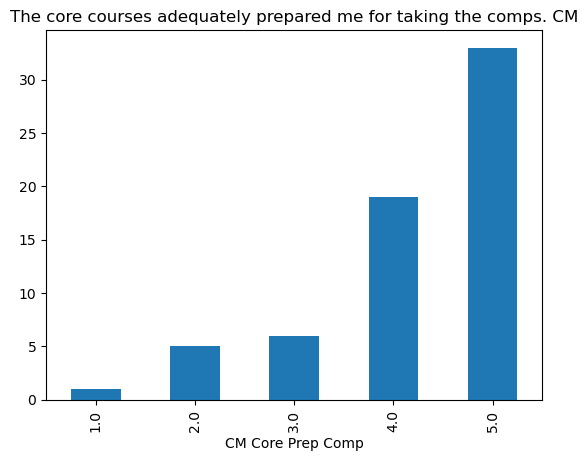

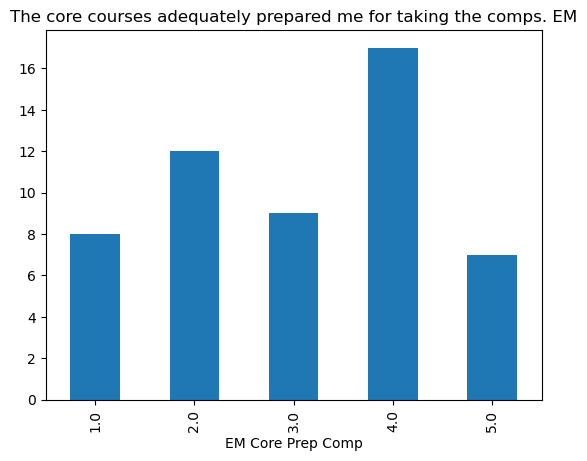

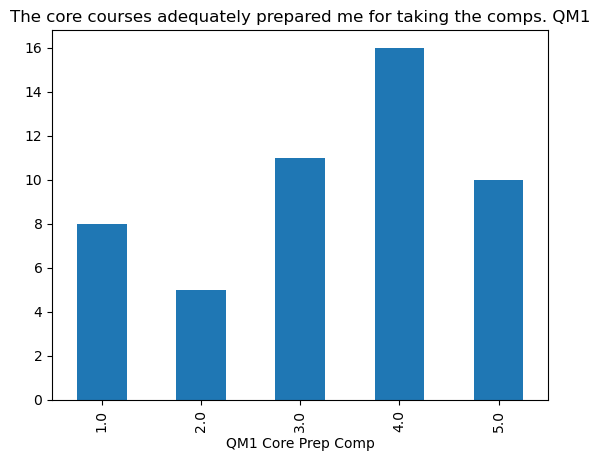

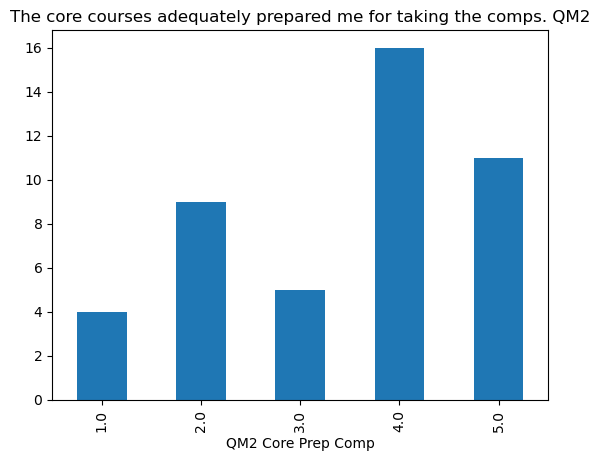

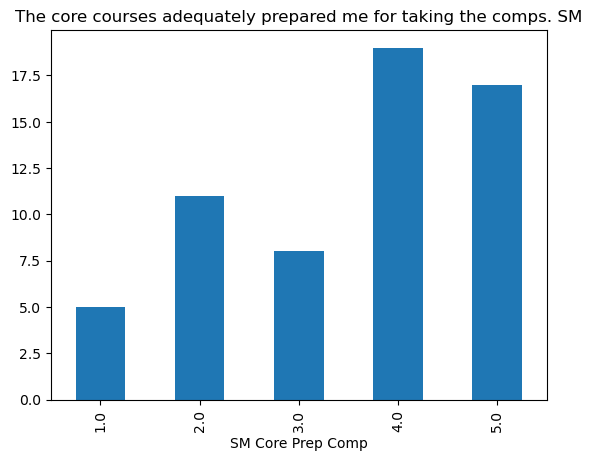

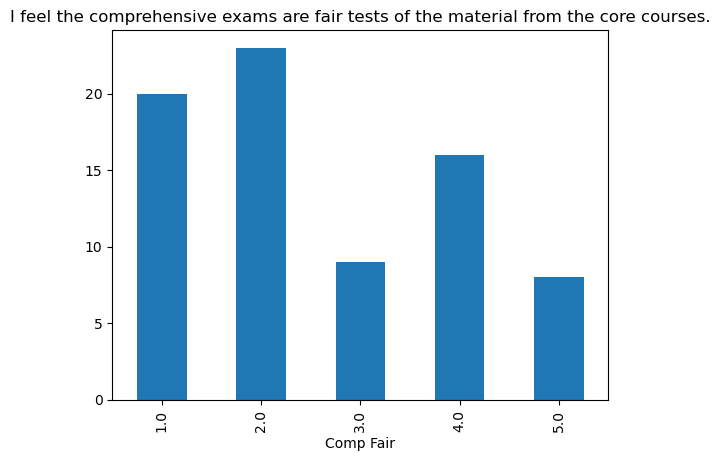

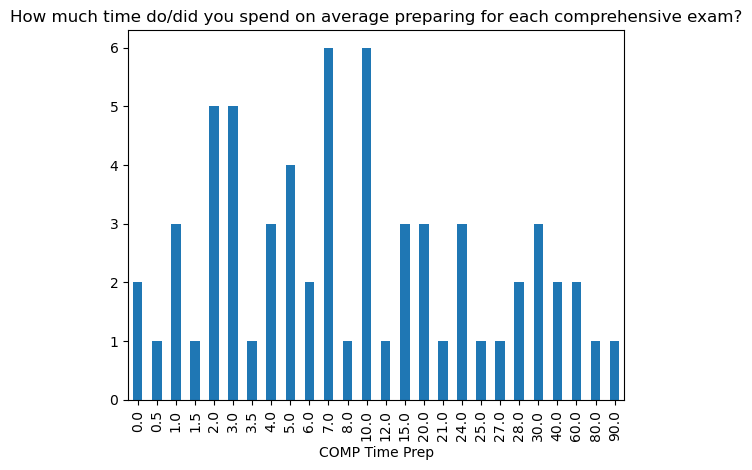

In [6]:
for var in CompsQuestions.keys():
    histogram(var, CompsQuestions)
    plt.show()

## Knowledge Gain from Taking the Comps

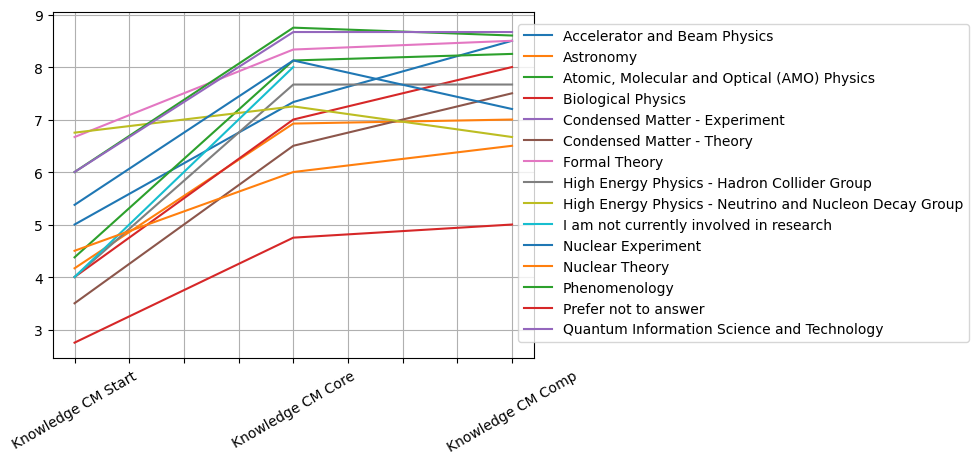

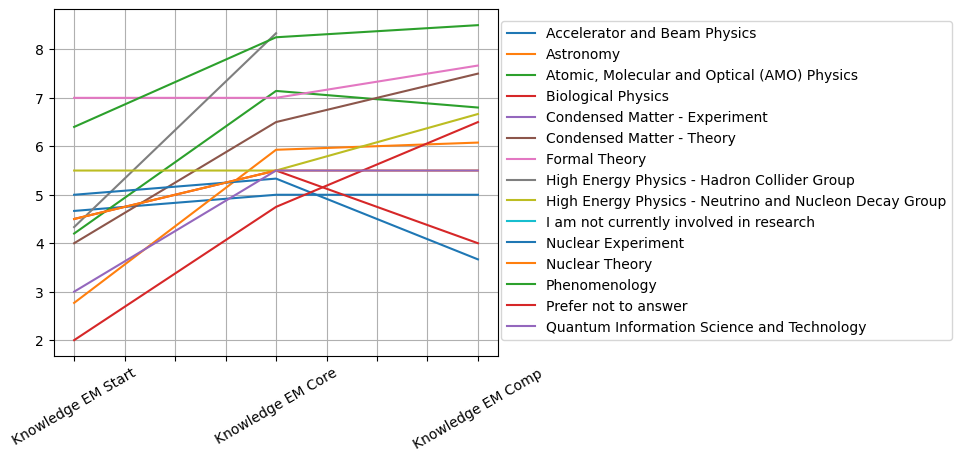

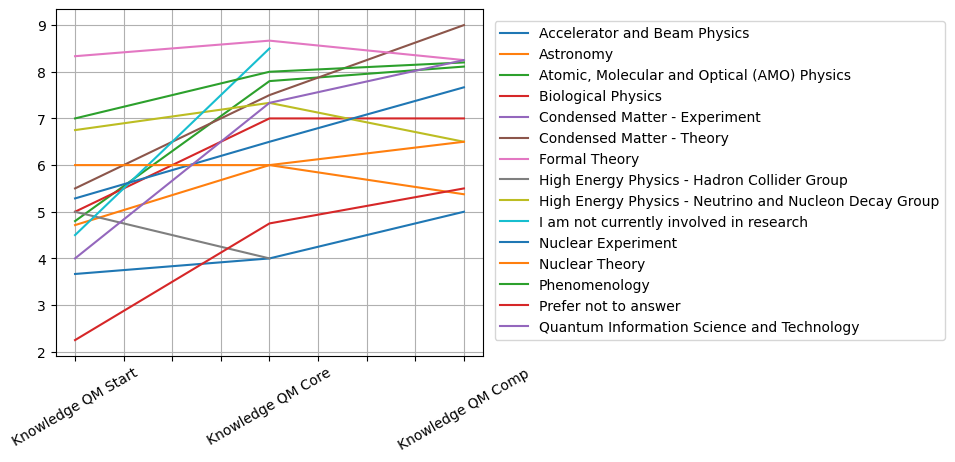

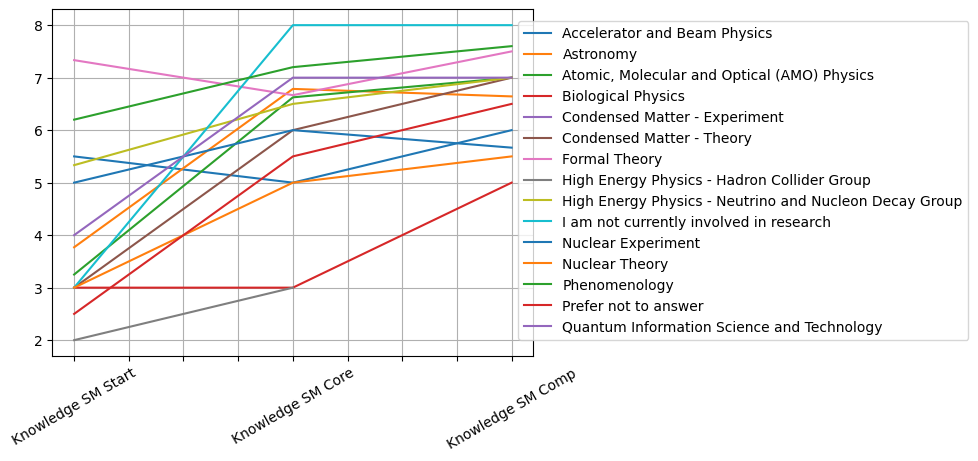

In [7]:
comps = ['CM','EM','QM','SM']
for comp in comps:
    ax=QOLDataExplode1.groupby('Research')[[f'Knowledge {comp} Start',f'Knowledge {comp} Core',f'Knowledge {comp} Comp']].agg('mean').transpose().plot(kind='line',legend=False,grid=True,rot=30)
    ax.set_aspect(0.24)
    fig=ax.get_figure()
    fig.set_size_inches(14,4.5)
    fig.legend(loc='outside center right',bbox_to_anchor=(1, 0.5))
    plt.show()

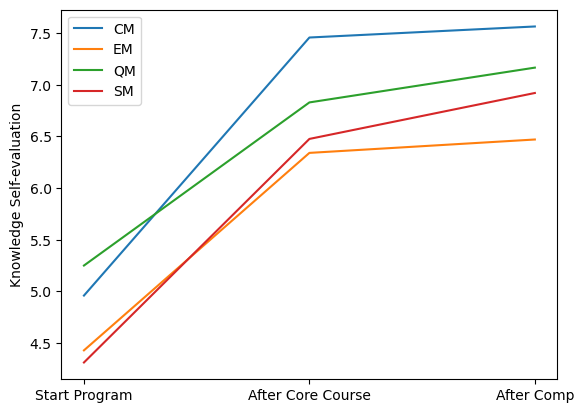

In [8]:
CM=QOLData[['Knowledge CM Start','Knowledge CM Core','Knowledge CM Comp']].agg('mean').transpose().reset_index(drop=True)

EM=QOLData[['Knowledge EM Start','Knowledge EM Core','Knowledge EM Comp']].agg('mean').transpose().reset_index(drop=True)

QM=QOLData[['Knowledge QM Start','Knowledge QM Core','Knowledge QM Comp']].agg('mean').transpose().reset_index(drop=True)
SM=QOLData[['Knowledge SM Start','Knowledge SM Core','Knowledge SM Comp']].agg('mean').transpose().reset_index(drop=True)
fig, ax = plt.subplots()
ax.plot(CM,label="CM")
ax.plot(EM,label="EM")
ax.plot(QM,label="QM")
ax.plot(SM,label="SM")
xticks = np.array([0,1,2])
xlabels = ["Start Program",'After Core Course','After Comp']
ax.set_xticks(xticks, labels=xlabels)
ax.set_ylabel("Knowledge Self-evaluation")
ax.legend()
plt.show()

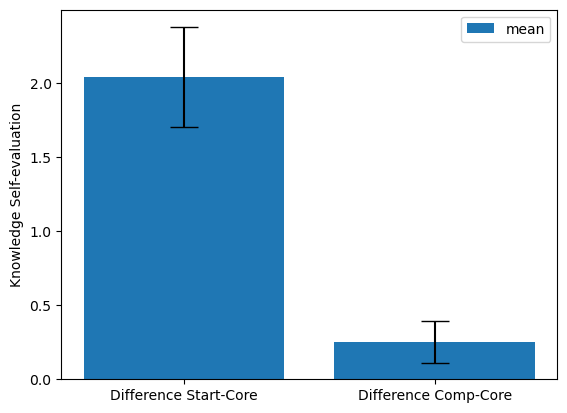

In [9]:
total=np.array([CM.values,EM.values,QM.values,SM.values])
diff_tot=np.array([total[:,1]-total[:,0], total[:,2]-total[:,1]])
v=diff_tot.mean(axis=1)
er=diff_tot.std(axis=1)

fig, ax = plt.subplots()
xticks = np.array([0,1])
ax.bar(xticks,v,label="mean",yerr=er,capsize=10)
xlabels = ["Difference Start-Core",'Difference Comp-Core']
ax.set_xticks(xticks, labels=xlabels)
ax.set_ylabel("Knowledge Self-evaluation")
ax.legend()
plt.show()

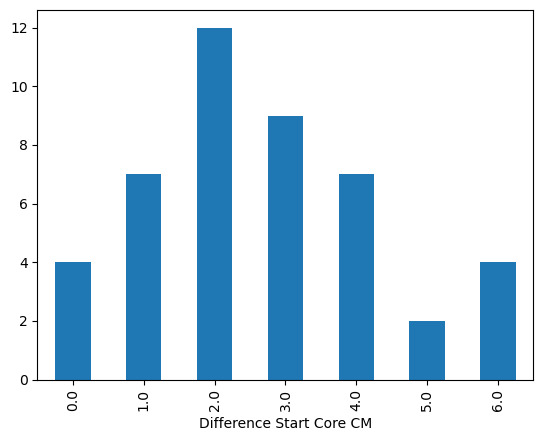

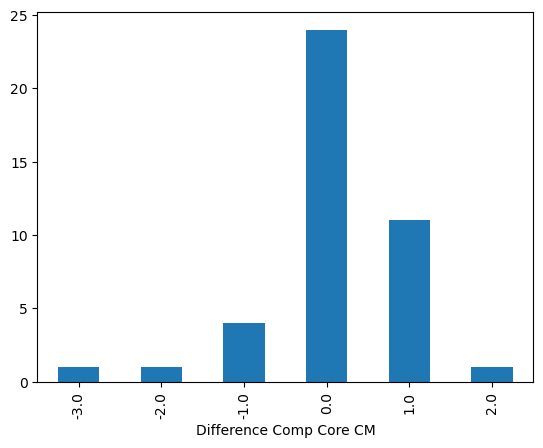

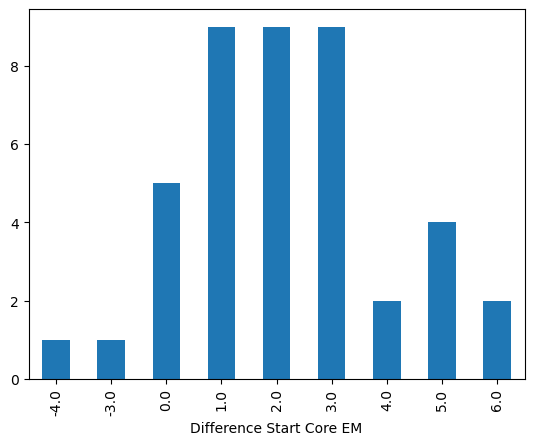

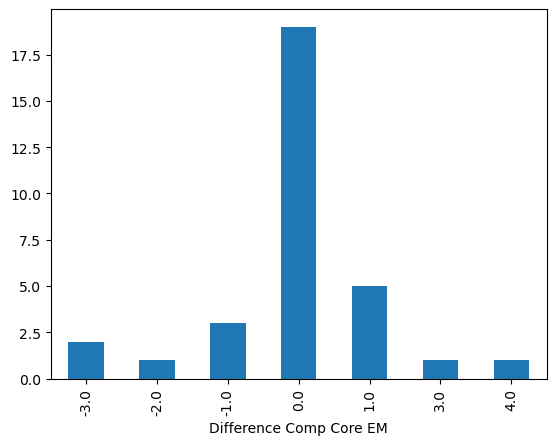

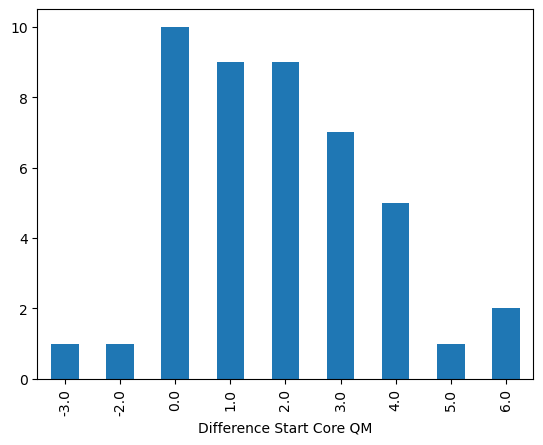

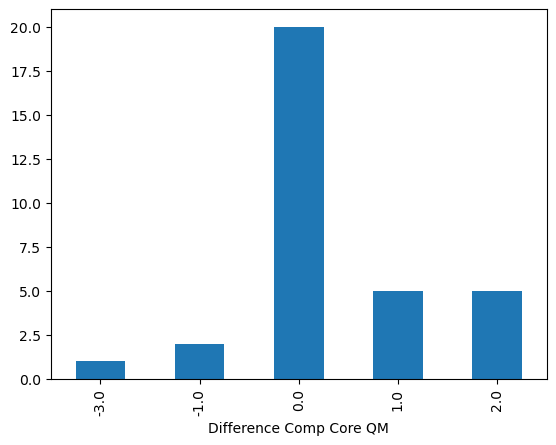

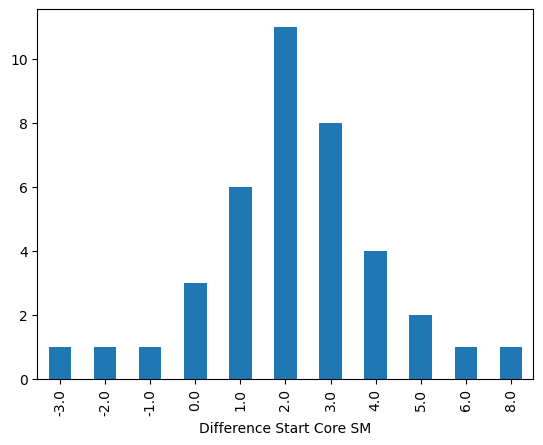

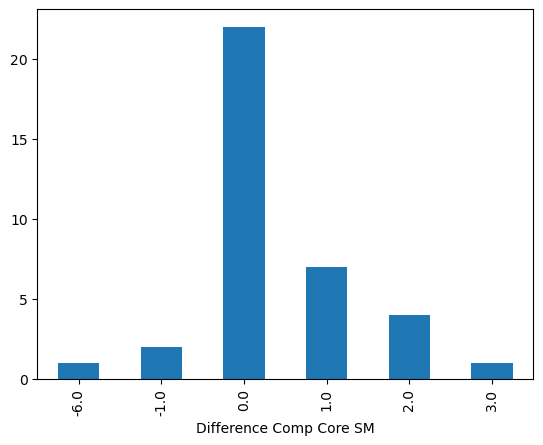

In [10]:
for comp in comps:
    QOLData[f'Difference Start Core {comp}']=QOLData[f'Knowledge {comp} Core']-QOLData[f'Knowledge {comp} Start']
    QOLData[f'Difference Comp Core {comp}']=QOLData[f'Knowledge {comp} Comp']-QOLData[f'Knowledge {comp} Core']
    ax=QOLData[f'Difference Start Core {comp}'].value_counts().sort_index().plot(kind='bar')
    fig=ax.get_figure()
    plt.show()
    ax=QOLData[f'Difference Comp Core {comp}'].value_counts().sort_index().plot(kind='bar')
    fig=ax.get_figure()
    plt.show()

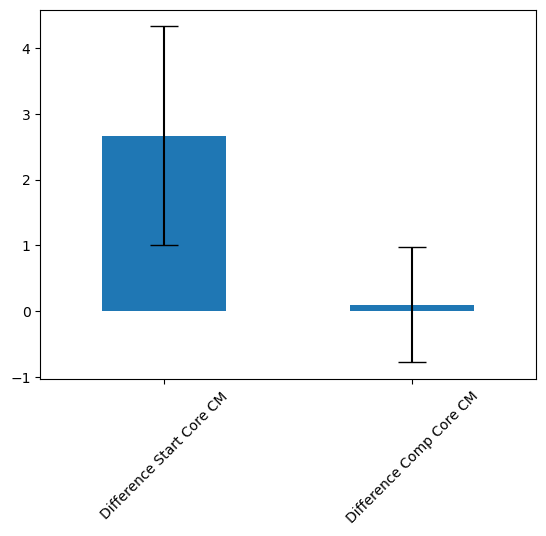

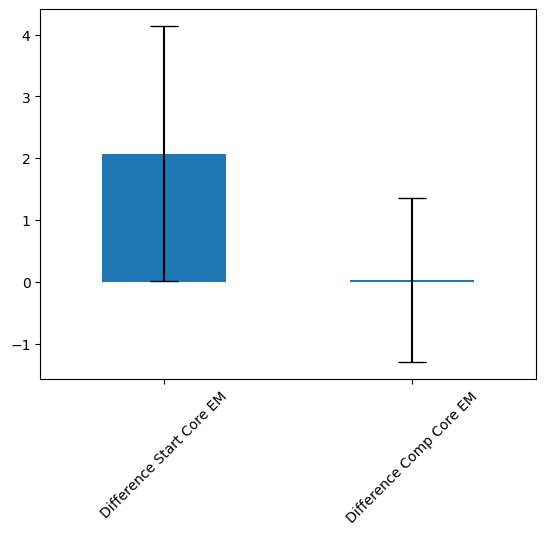

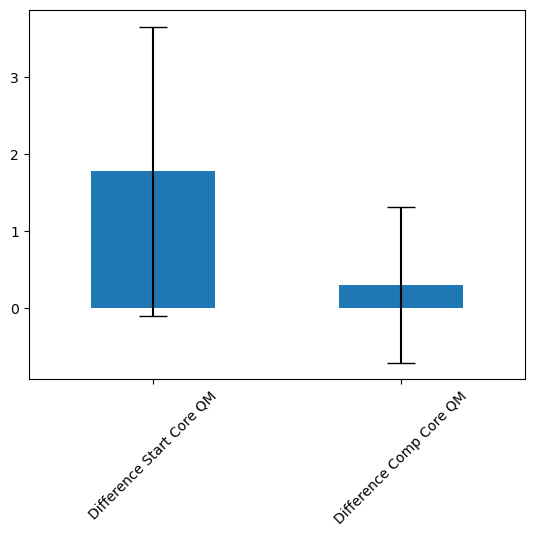

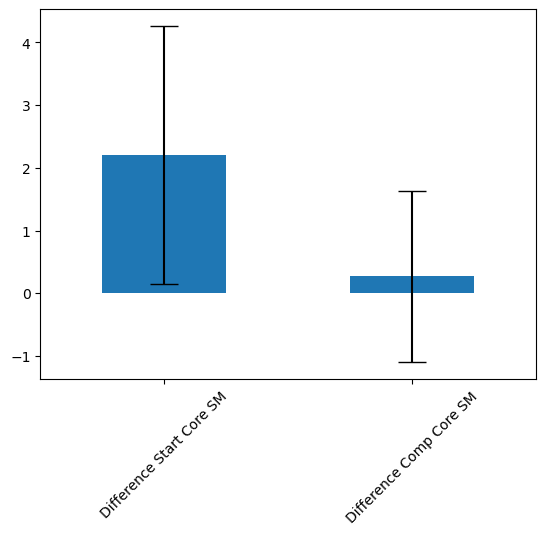

In [11]:
for comp in comps:
    column=QOLData[[f'Difference Start Core {comp}',f'Difference Comp Core {comp}']]
    ax=column.agg('mean').plot(kind='bar',yerr=column.agg('std'),capsize=10,rot = 45)
    fig=ax.get_figure()
    plt.show()

## Financial Cost of the Comps

['Research Assistant or Graduate Assistant', 'Other', 'Not Paid', 'Teaching Assistant']


Cost of Comps     2319.519444
Monthly Income    2261.673469
COMP Time Prep      16.923913
dtype: float64

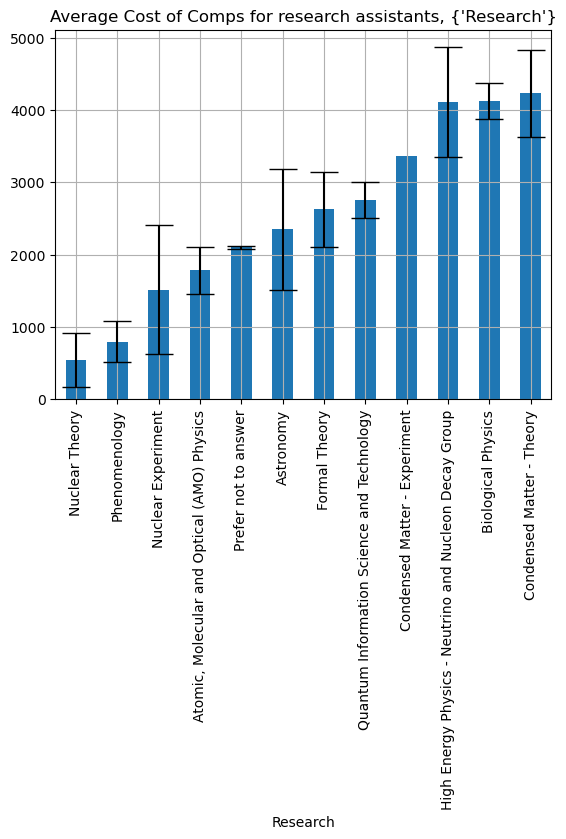

In [12]:
QOLDataExplode1["Cost of Comps"]= QOLDataExplode1['Monthly Income']*QOLDataExplode1["COMP Time Prep"]/20
b=list(QOLDataExplode1['Job'].values.unique())
print(b)
A=QOLDataExplode1[QOLDataExplode1['Job']==b[0]]
val=A.groupby('Research')['Cost of Comps'].agg('mean').sort_values().dropna().plot(kind='bar',grid=True,
            yerr=QOLDataExplode1.groupby('Research')['Monthly Income'].agg('std'),capsize=10,title="Average Cost of Comps for research assistants, {'Research'}")
A[["Cost of Comps",'Monthly Income',"COMP Time Prep"]].agg("mean")

## Comps Questions versus Everything

In [18]:
def barplot(factor,column,questions):
    if QOLDataExplode1[column].dtype != 'category' and QOLDataExplode1[factor].dtype == 'category':
        if factor=='Research' or factor =='Race':
            R=90
        else: 
            R=60
        ax=QOLDataExplode1.groupby(factor)[column].agg('mean').sort_values().plot(kind='bar',grid=True,
            yerr=QOLDataExplode1.groupby(factor)[column].agg('std'),capsize=10,title=f"{questions[column]} {factor}",rot = R)
        ax.set_axisbelow(True)
        ax.set_ylim(bottom=0)
        fig=ax.get_figure()
        fig.set_size_inches(10,5)
        plt.show()

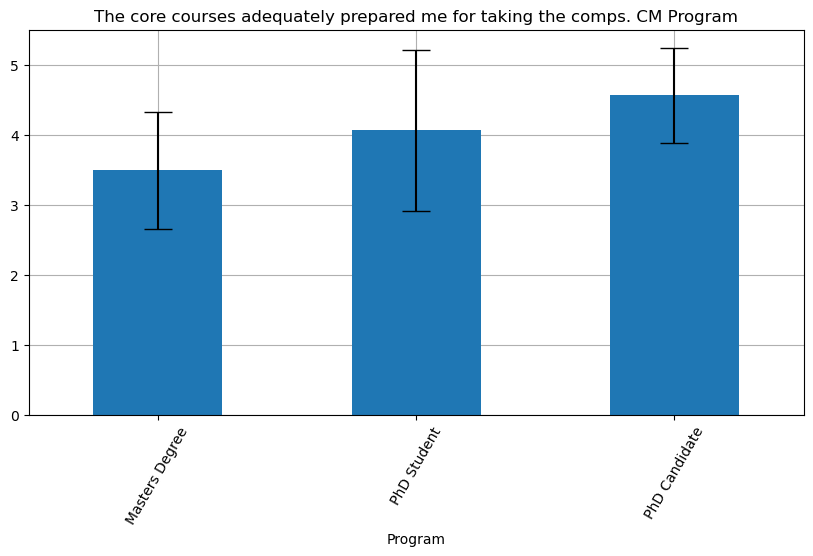

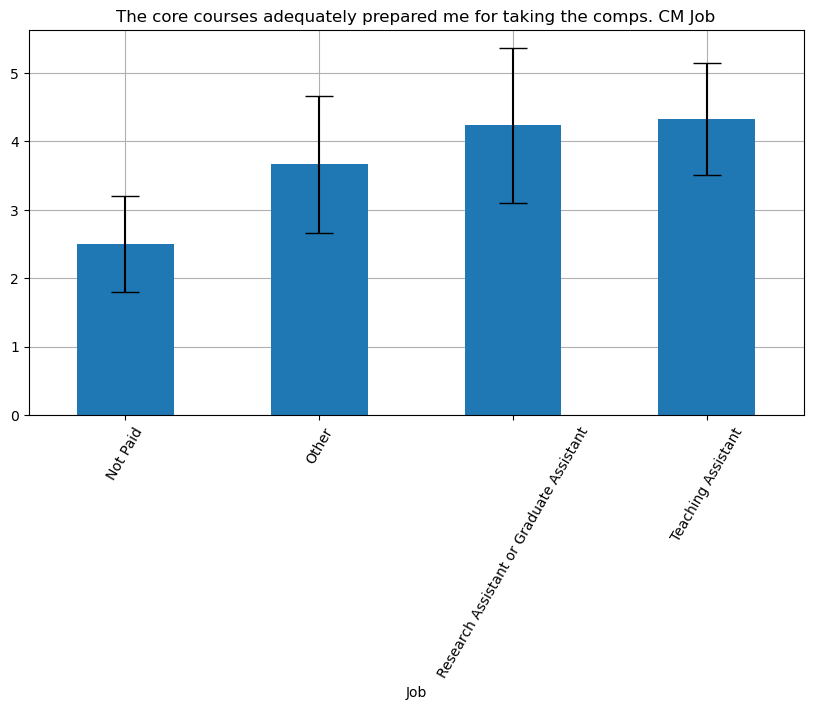

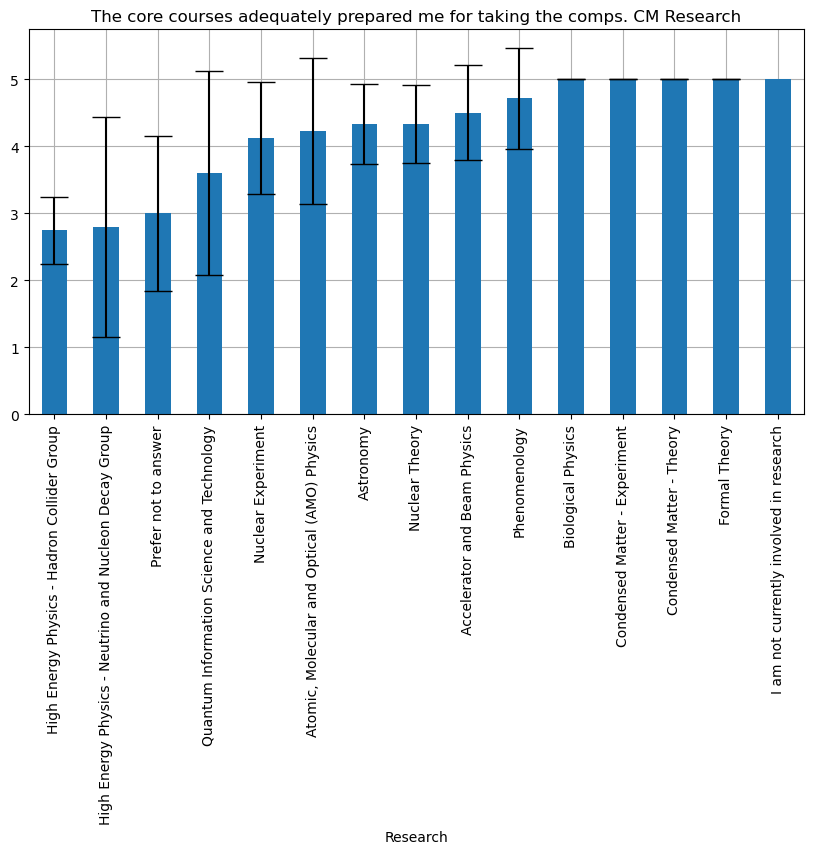

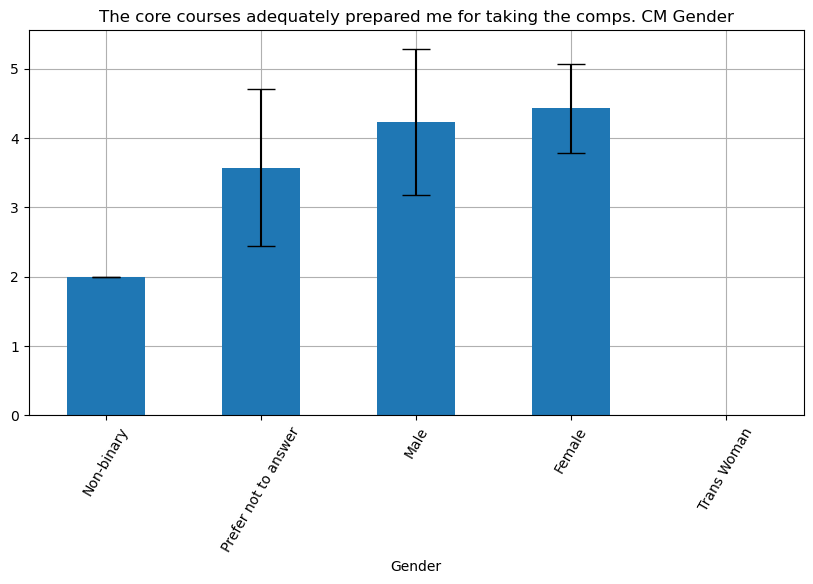

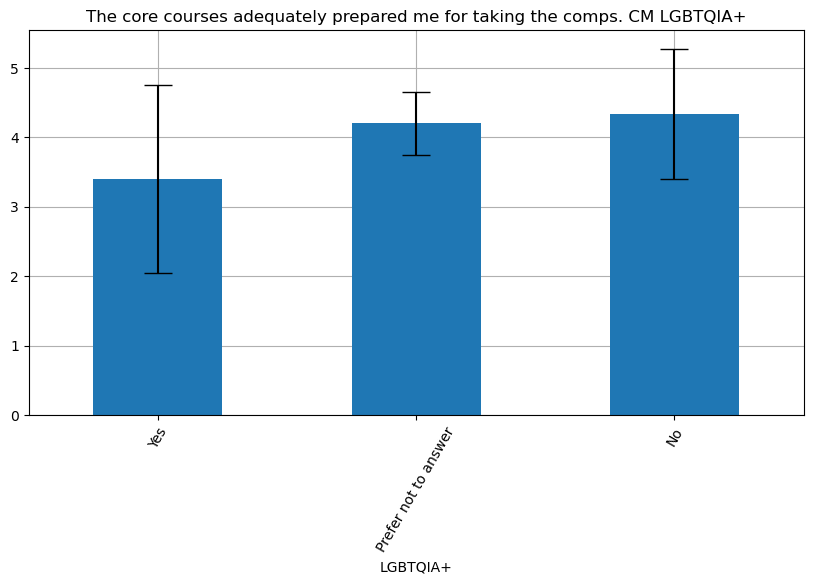

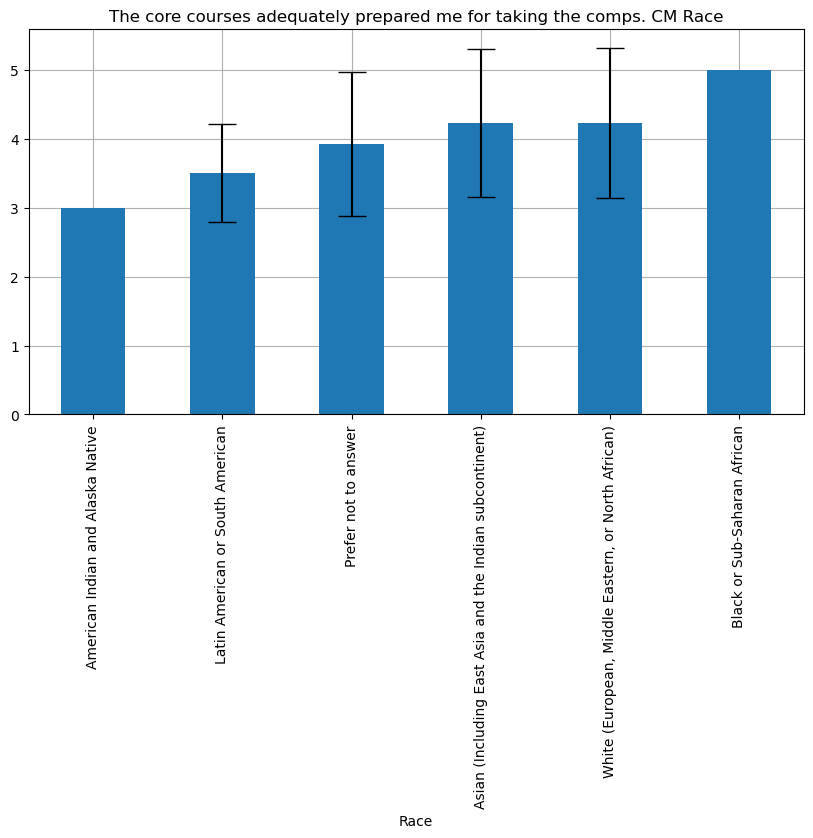

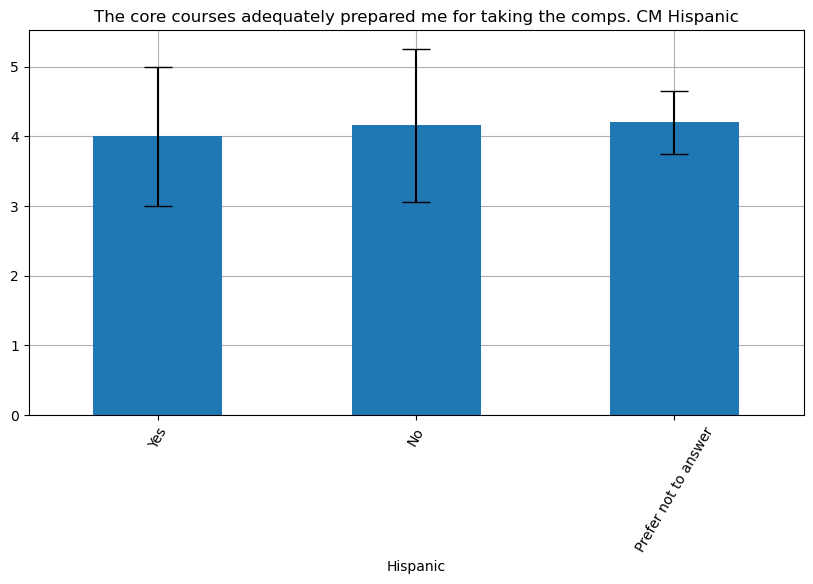

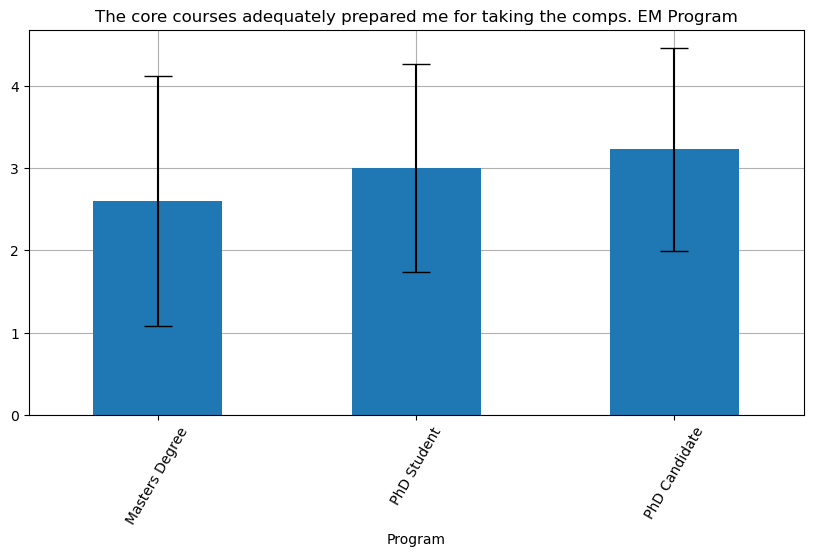

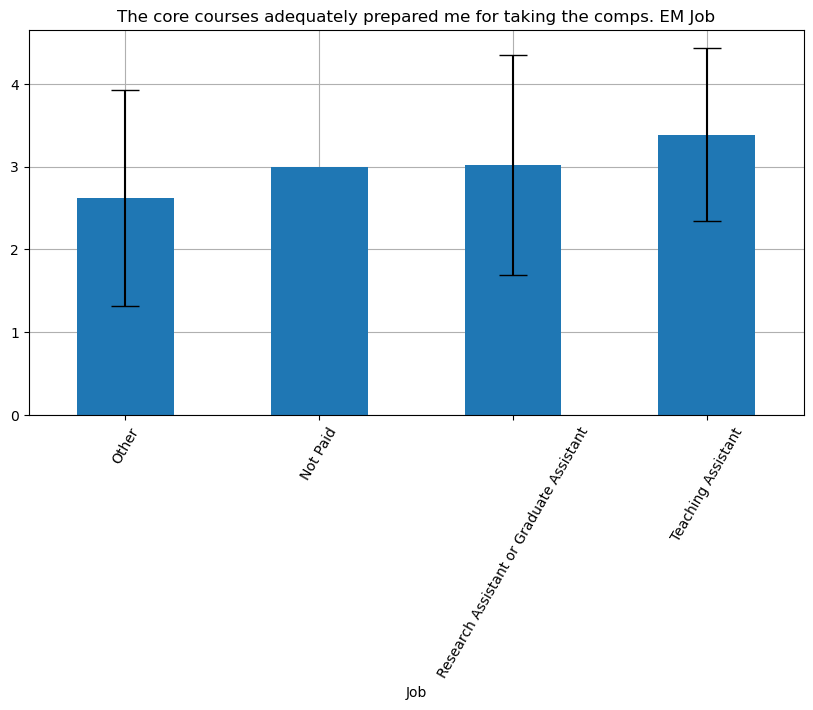

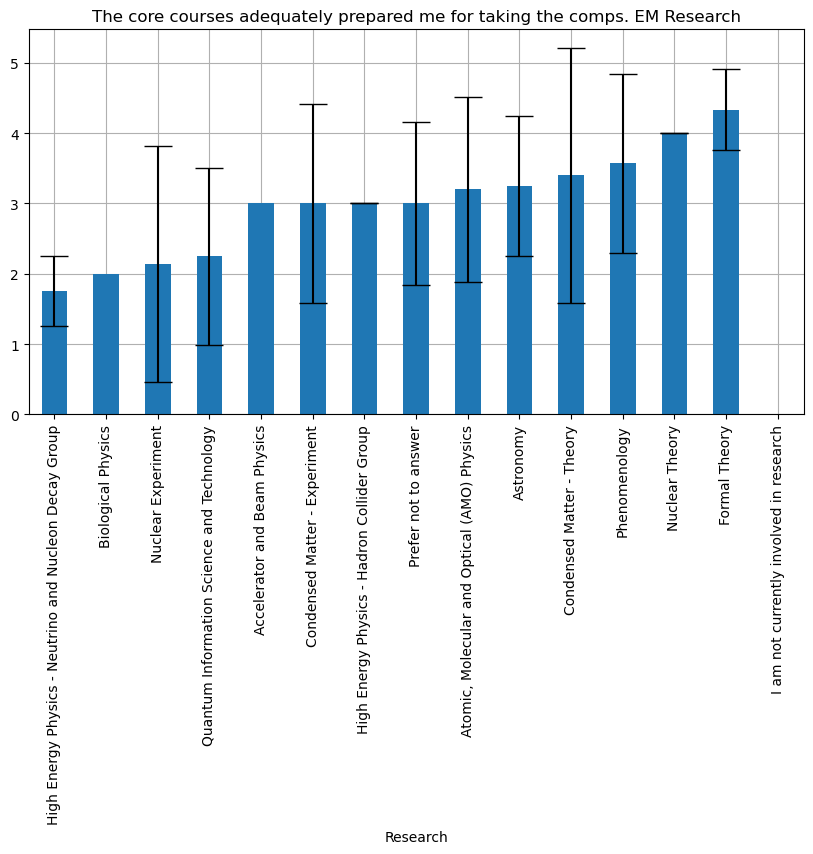

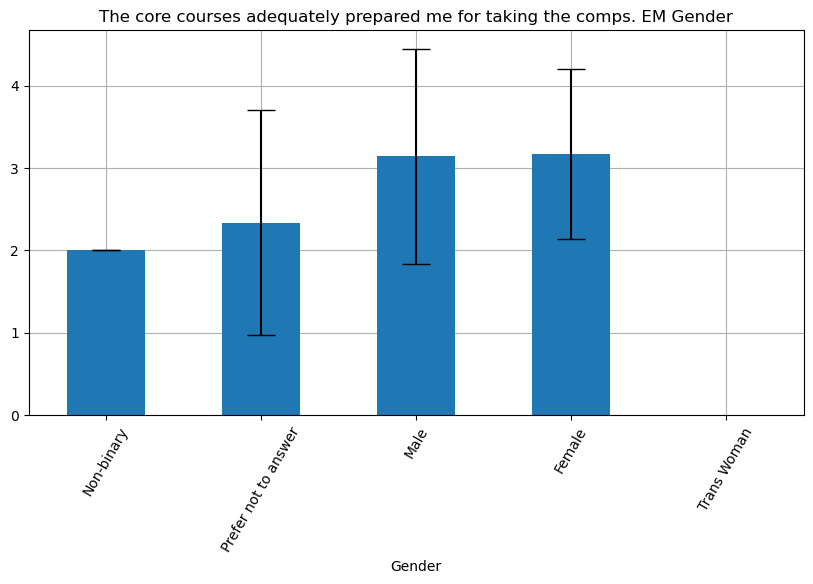

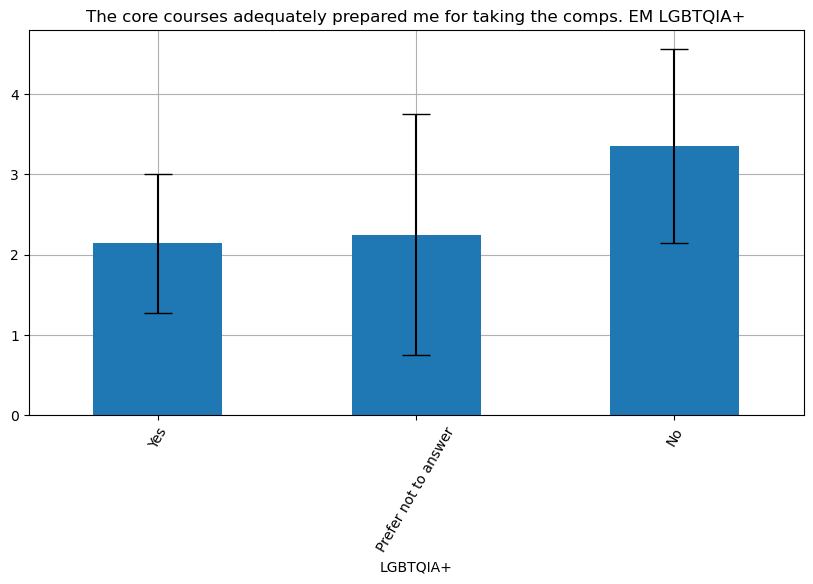

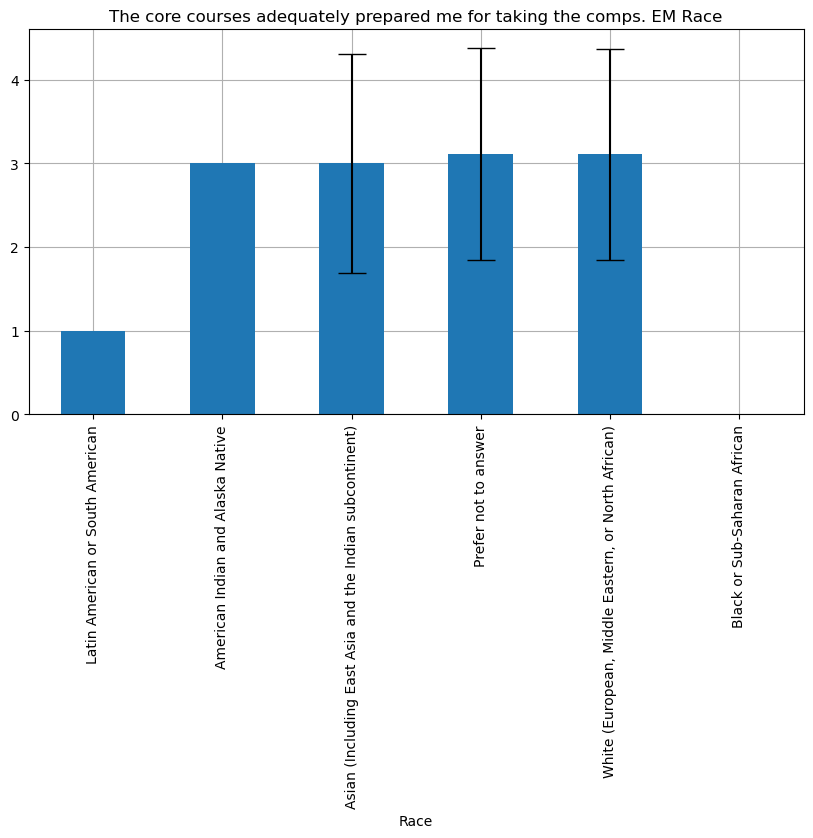

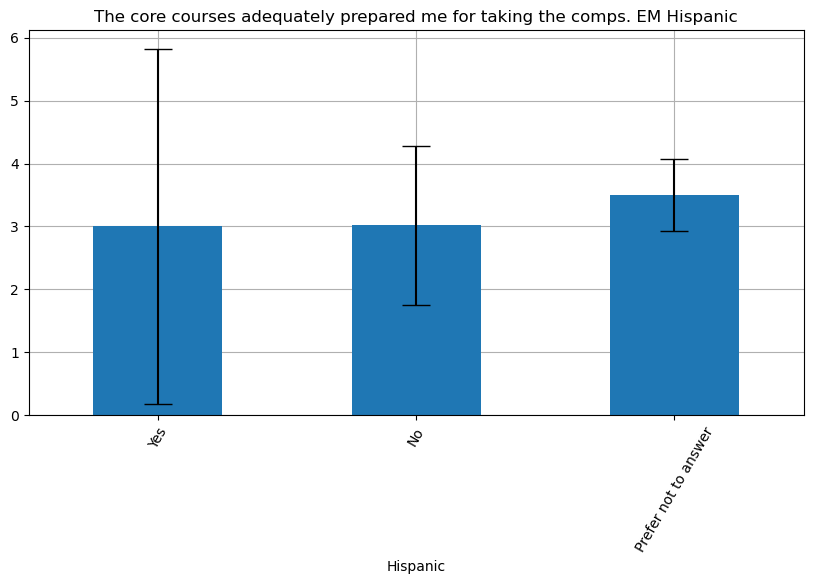

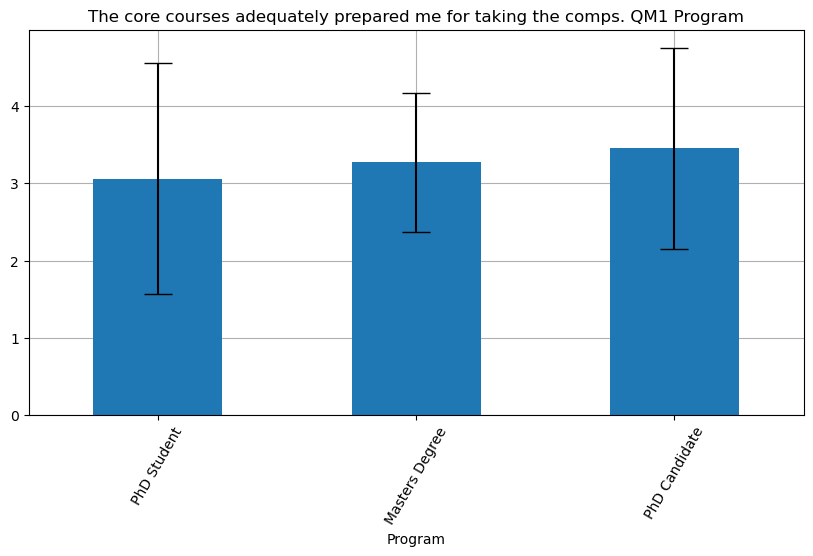

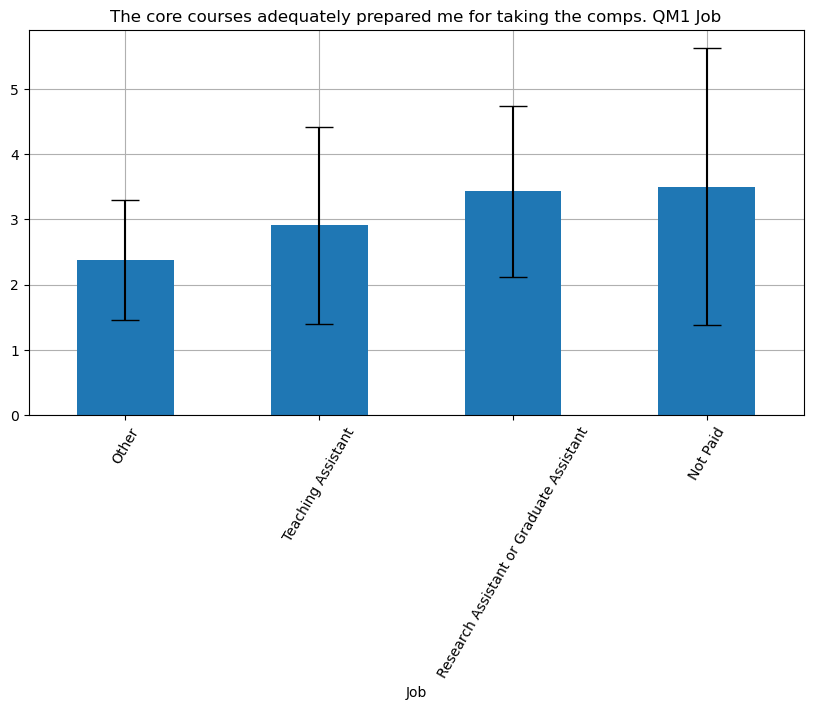

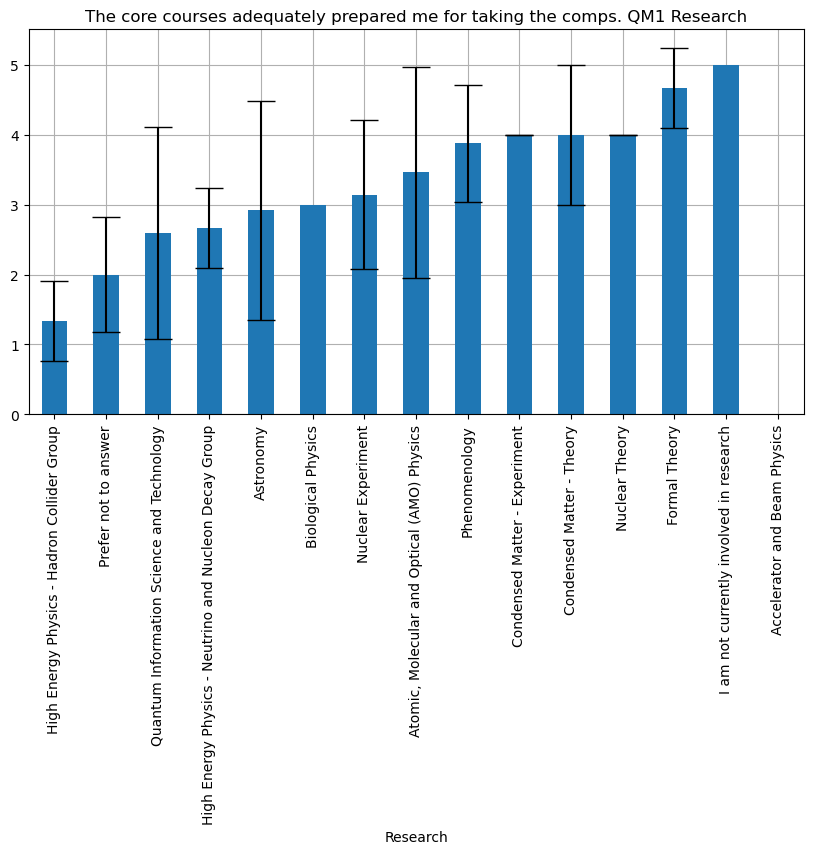

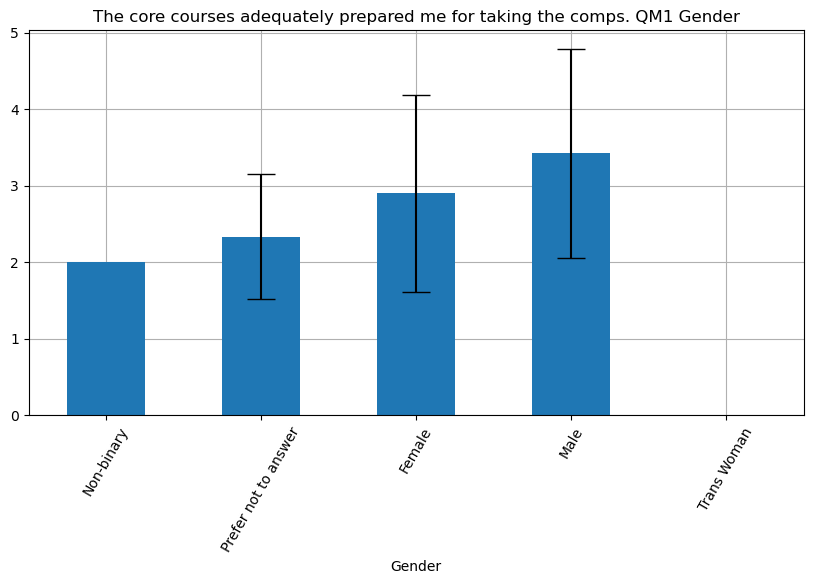

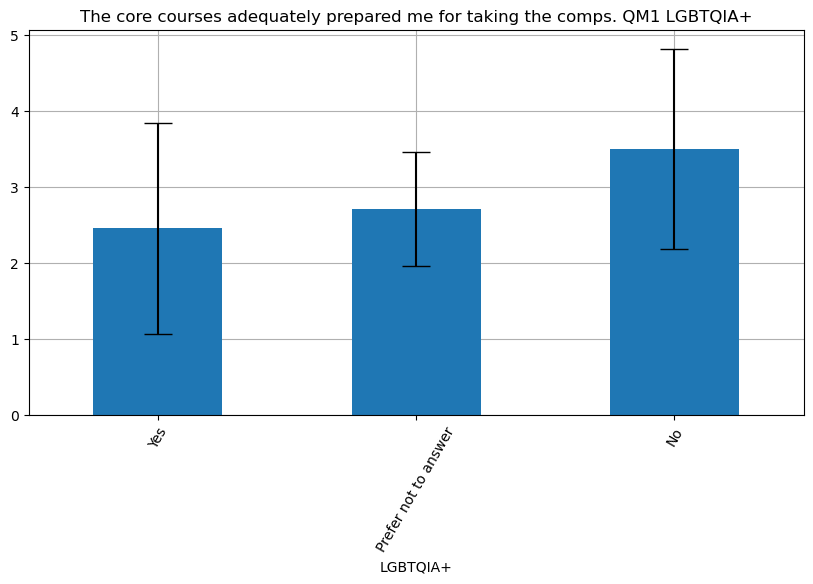

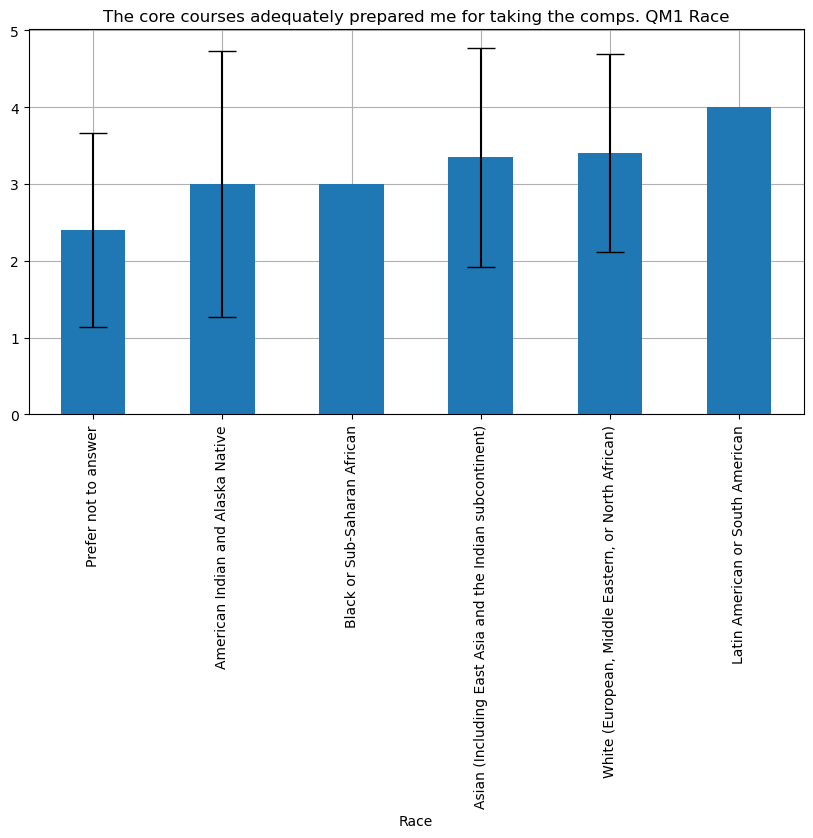

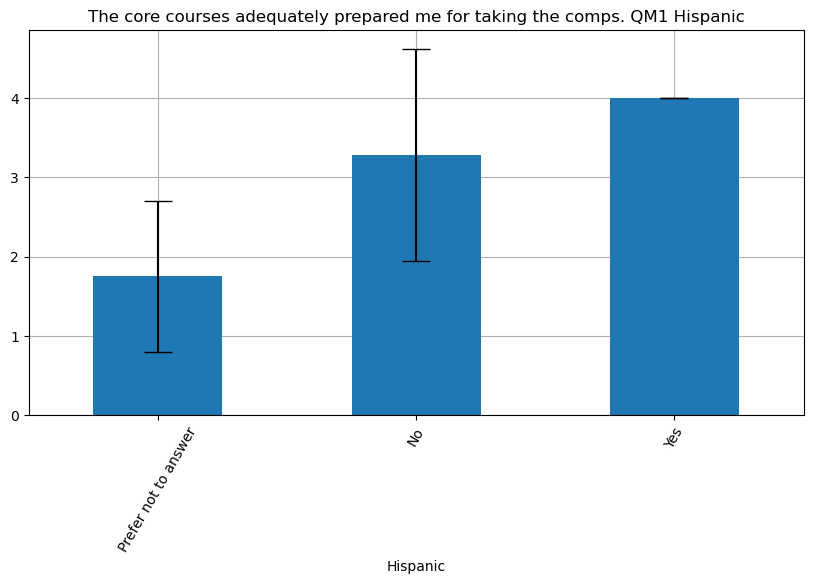

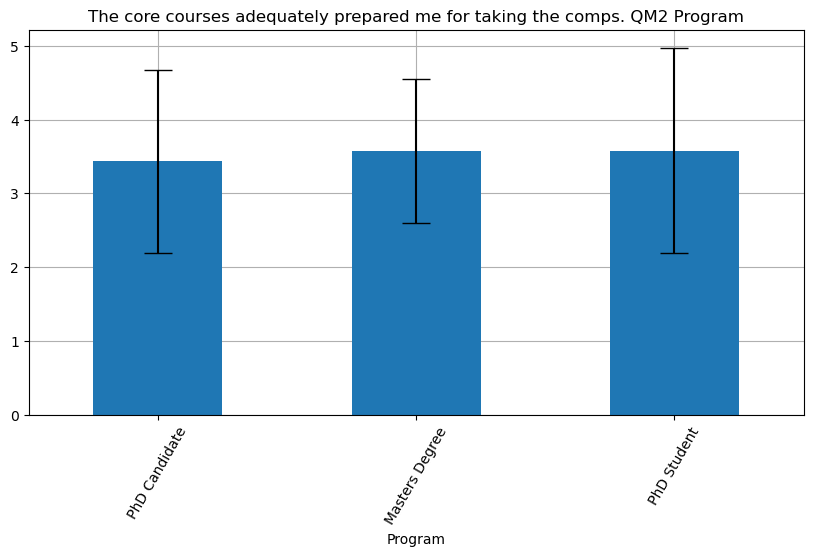

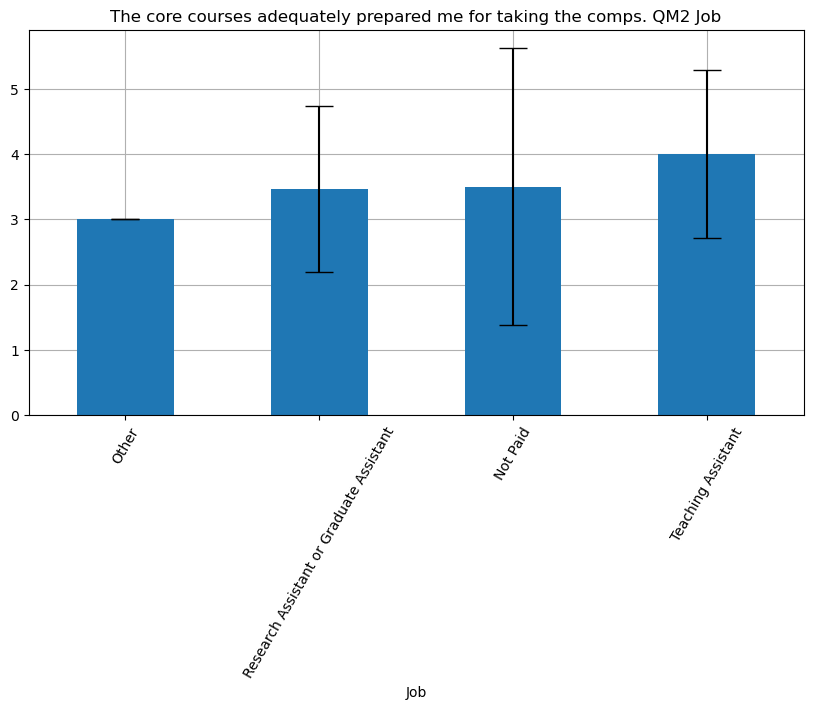

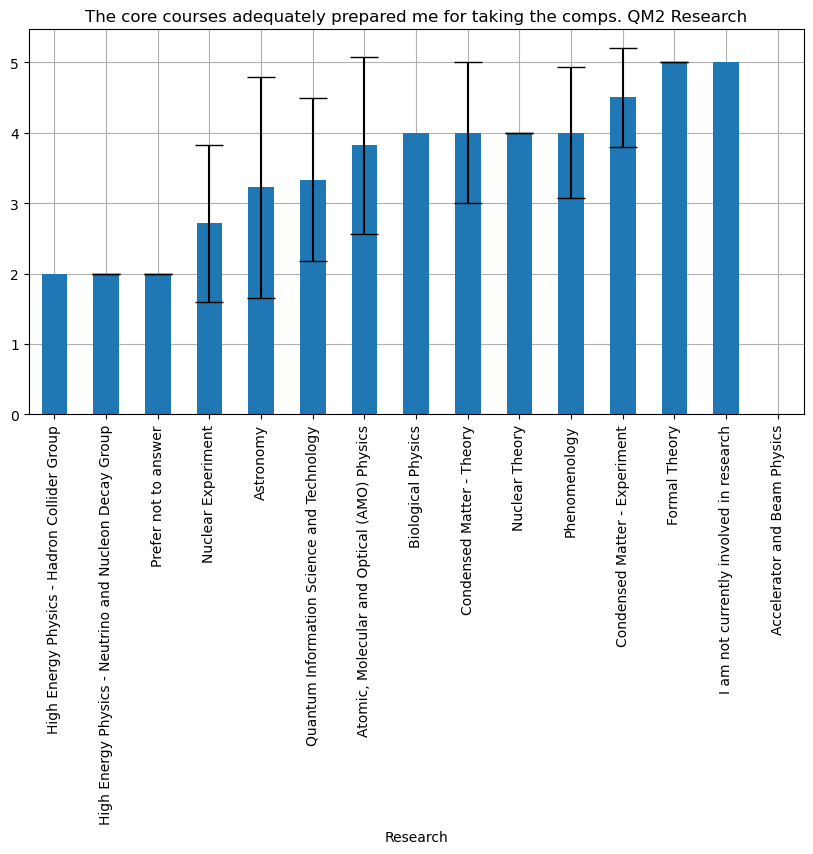

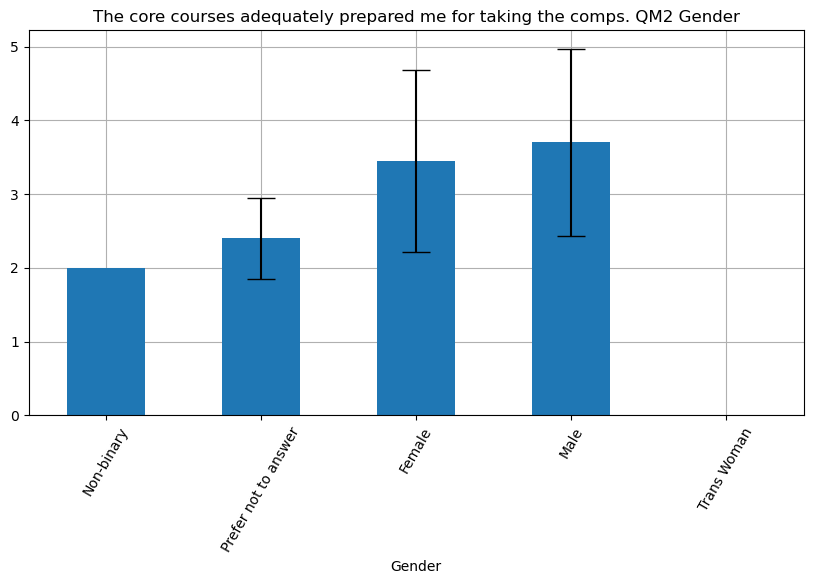

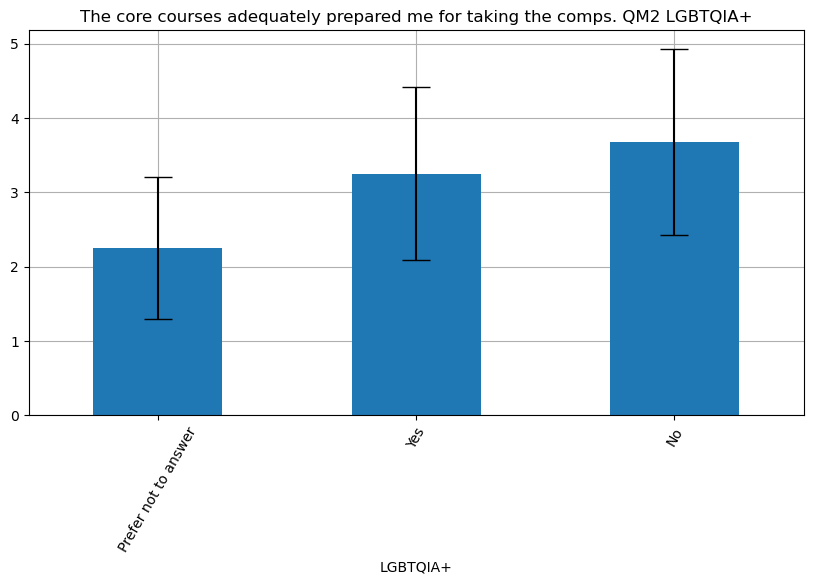

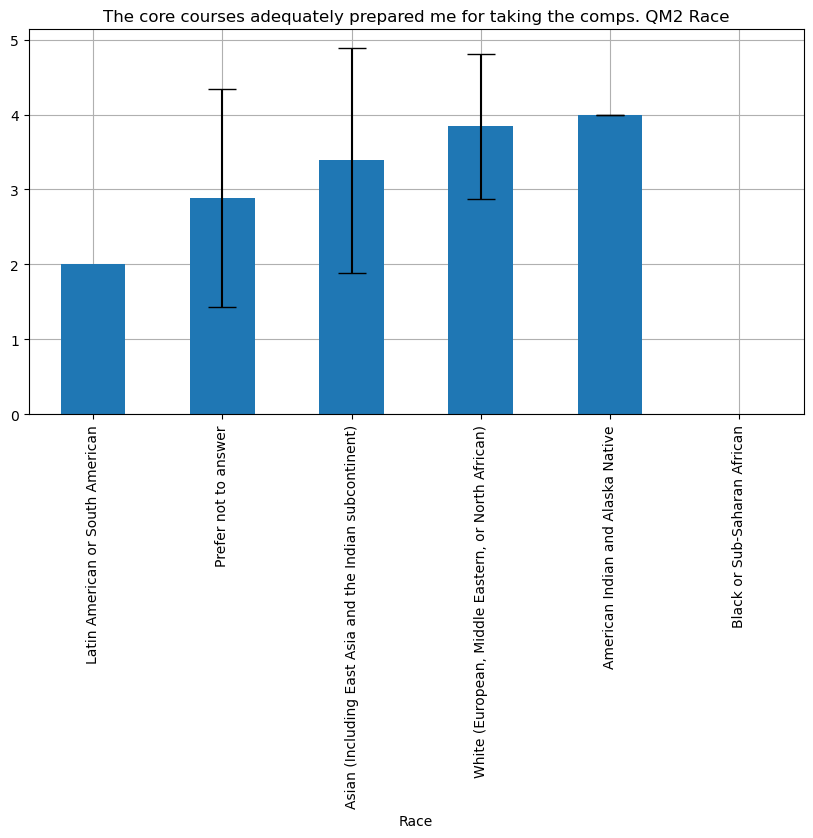

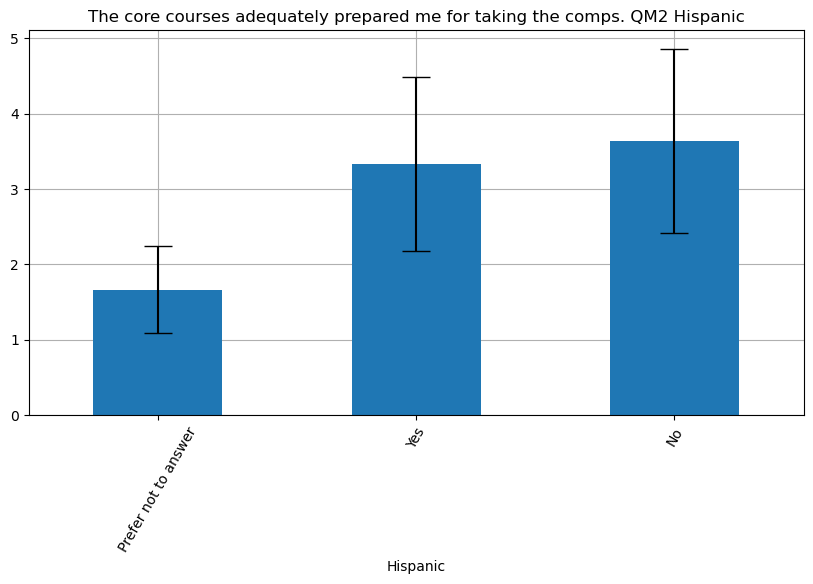

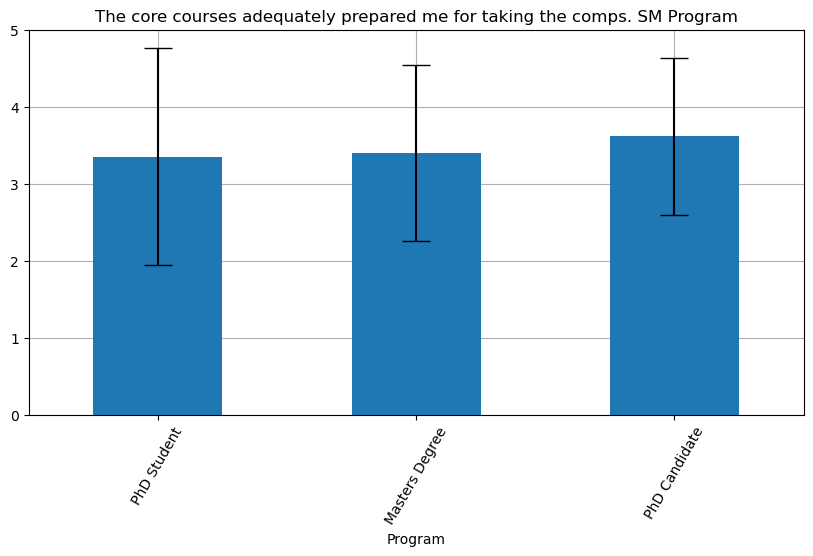

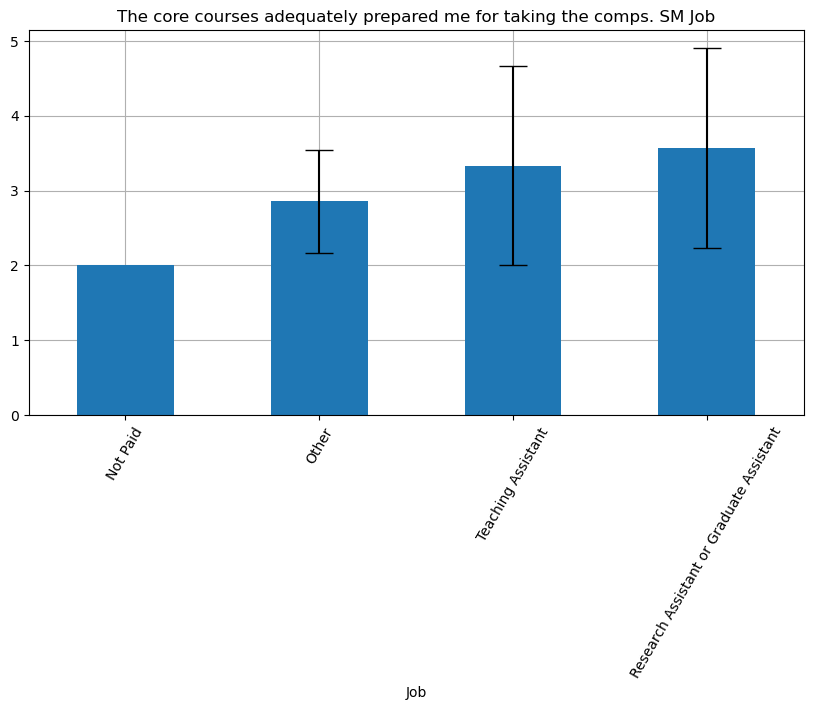

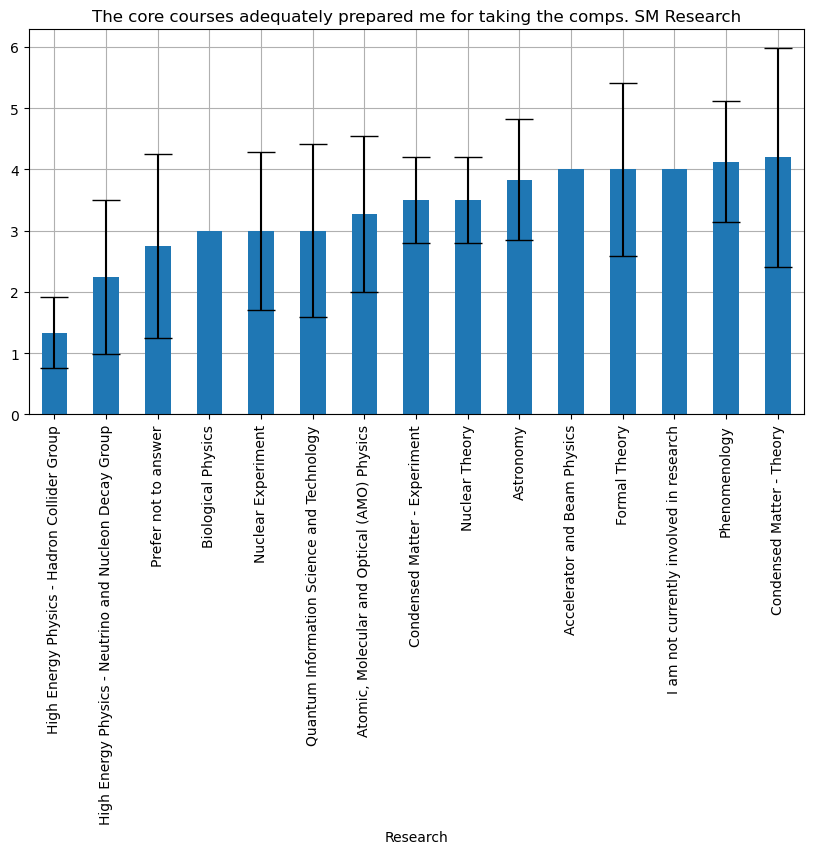

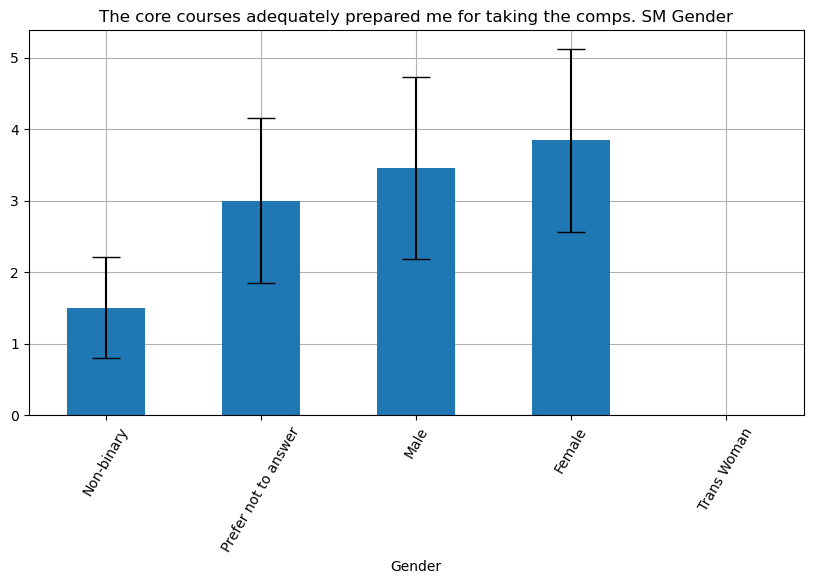

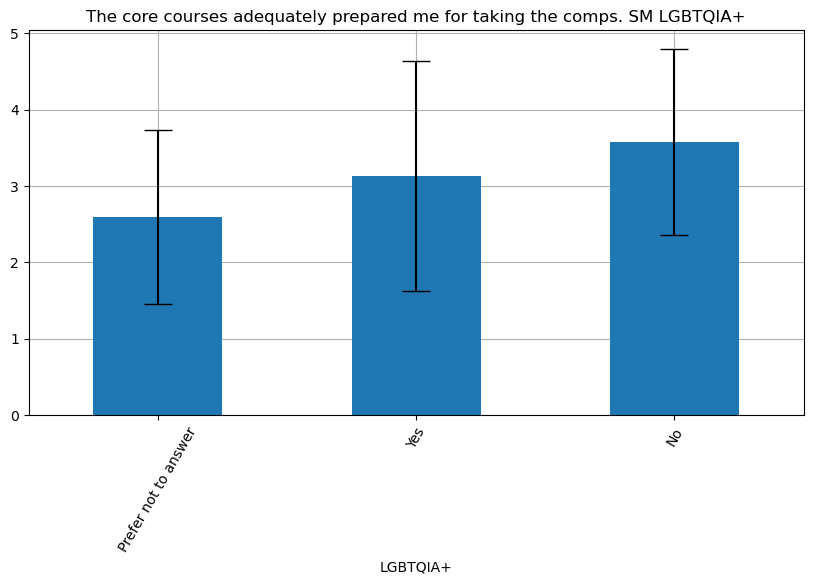

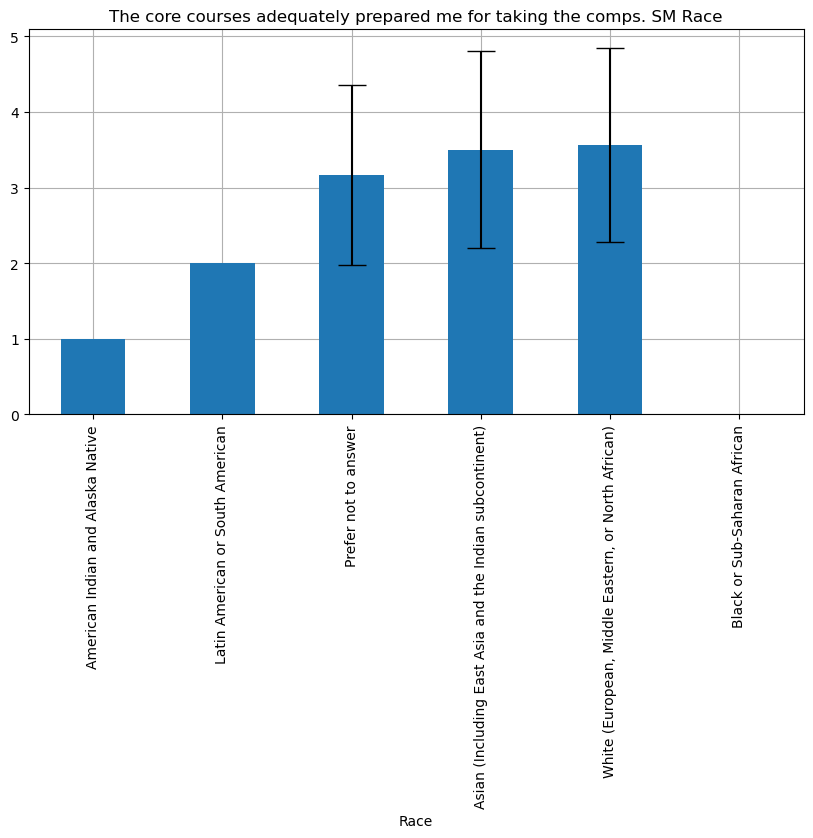

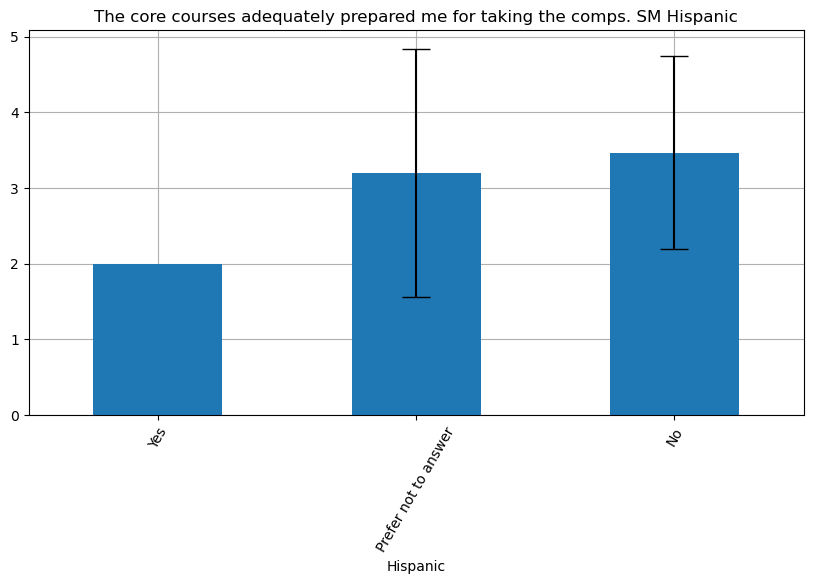

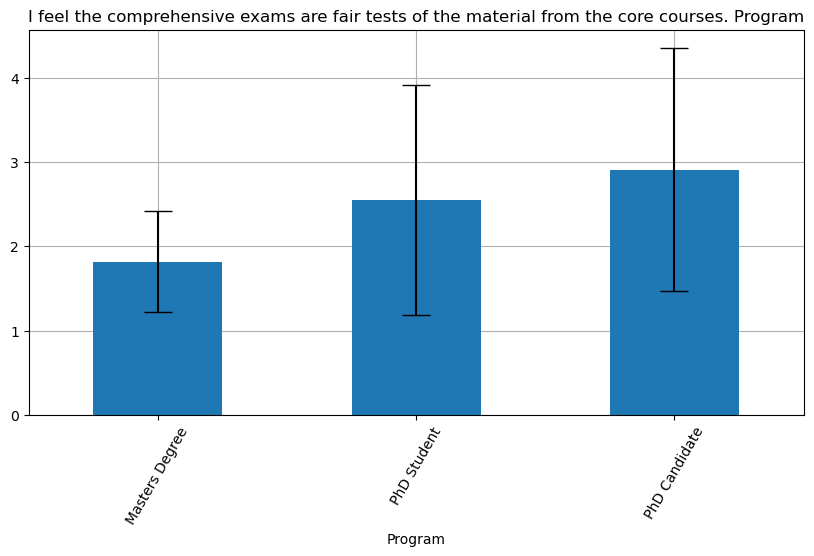

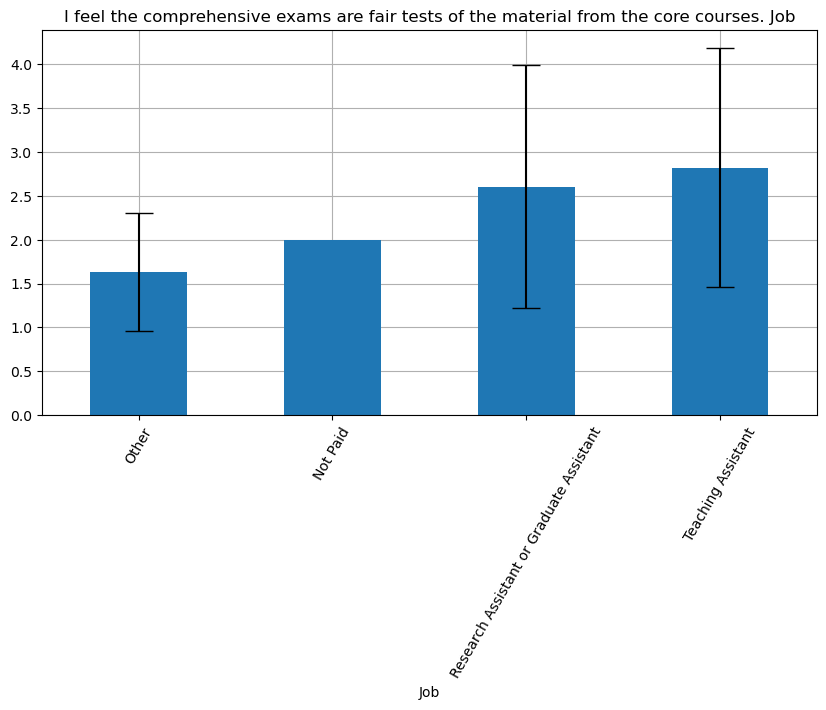

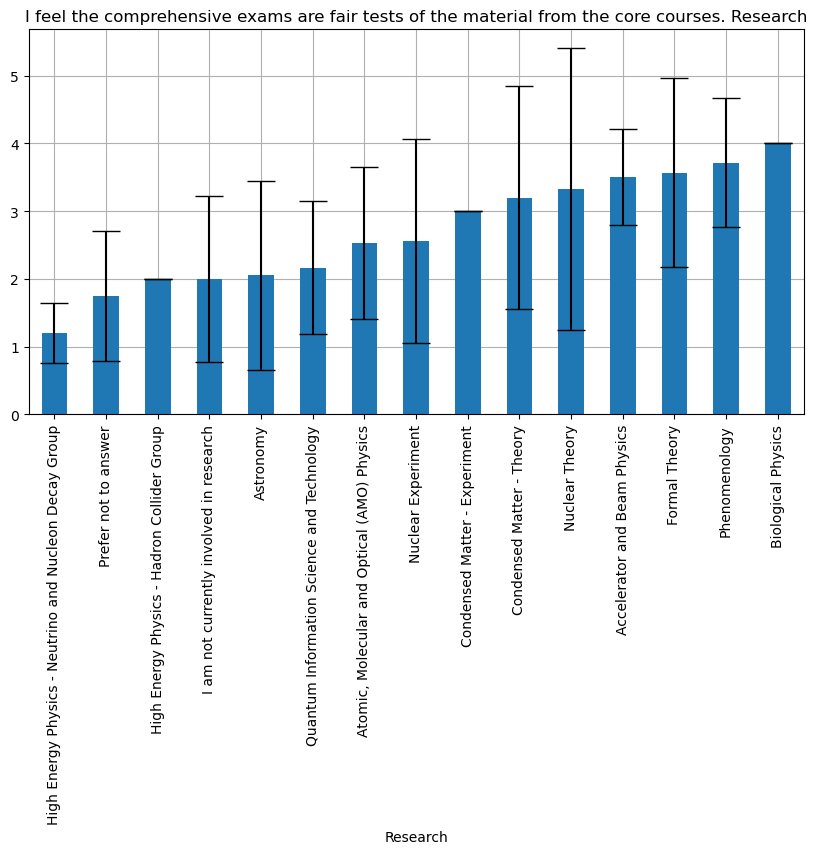

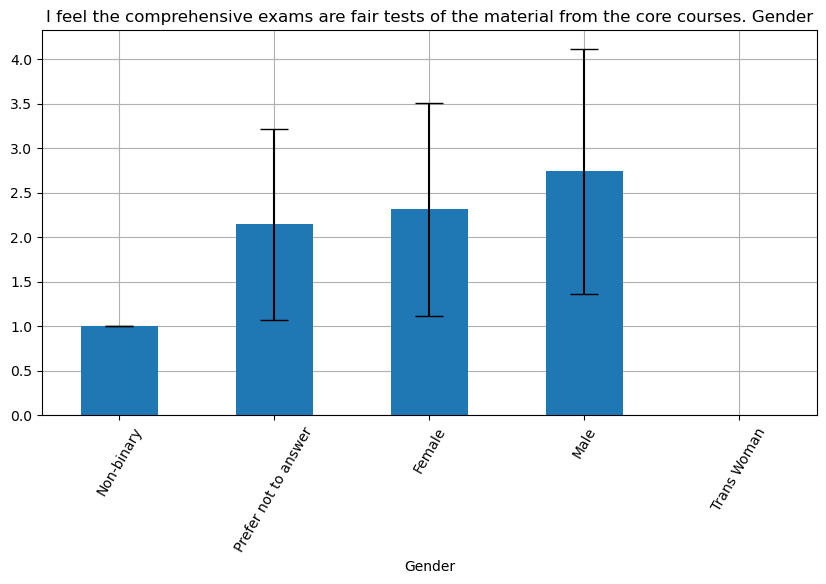

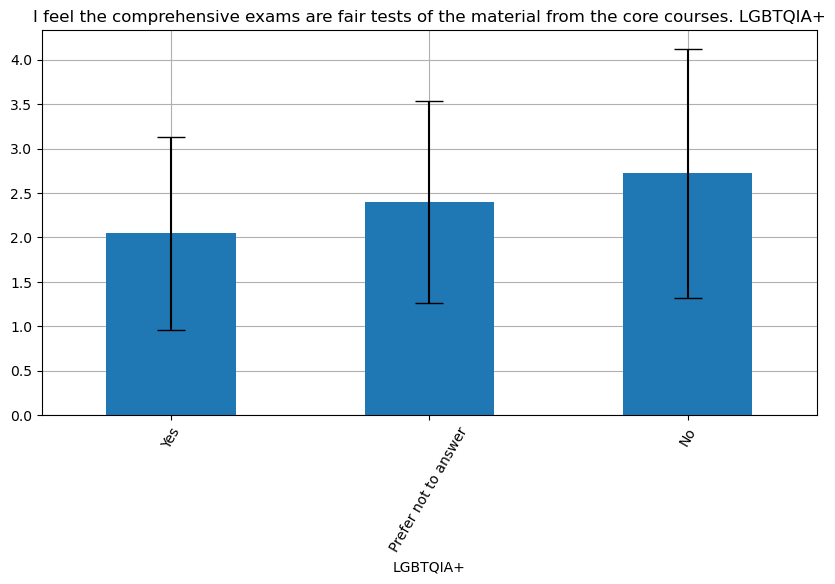

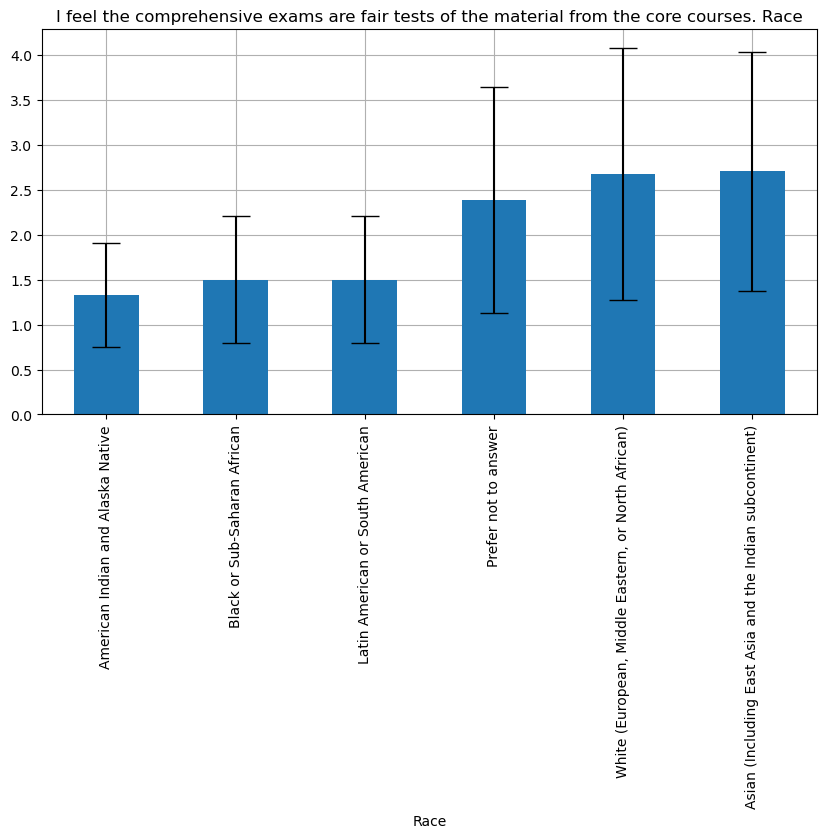

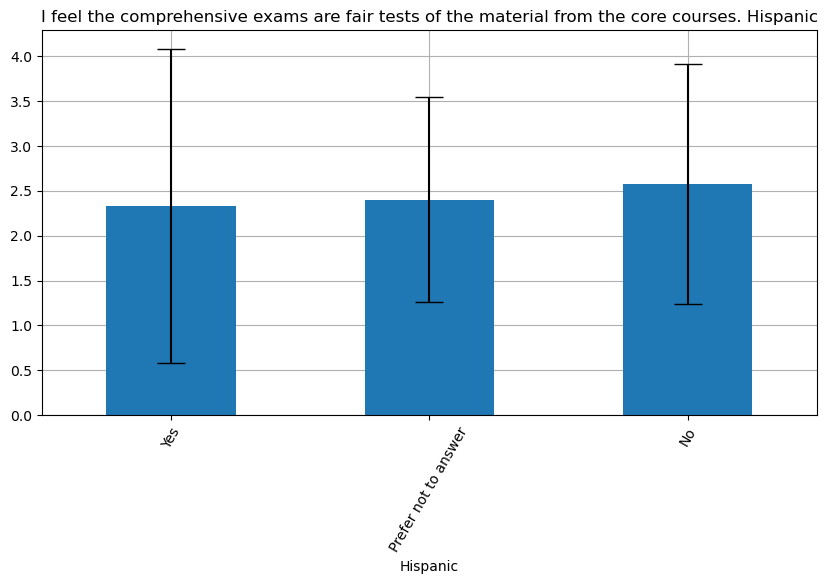

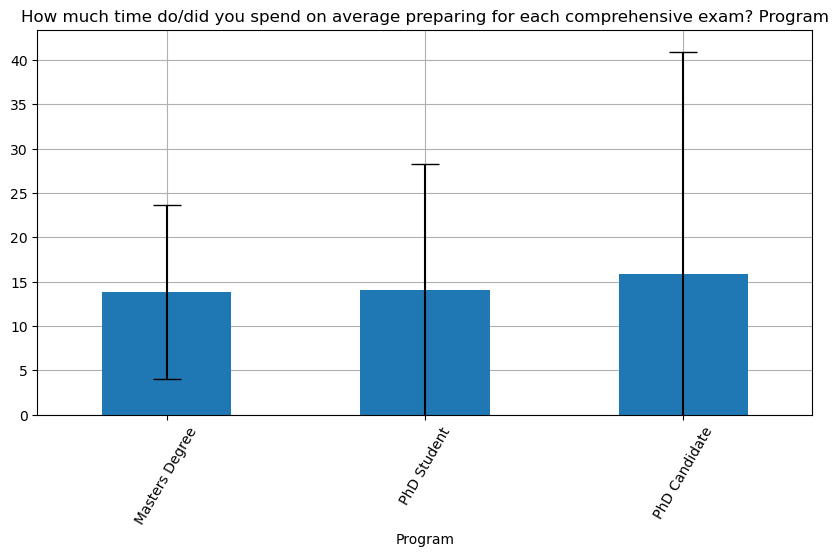

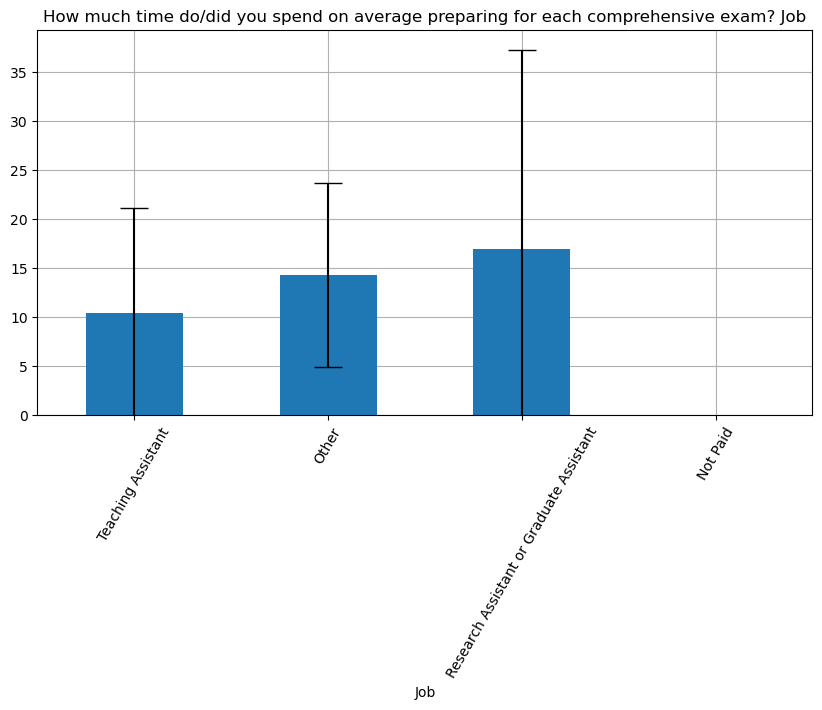

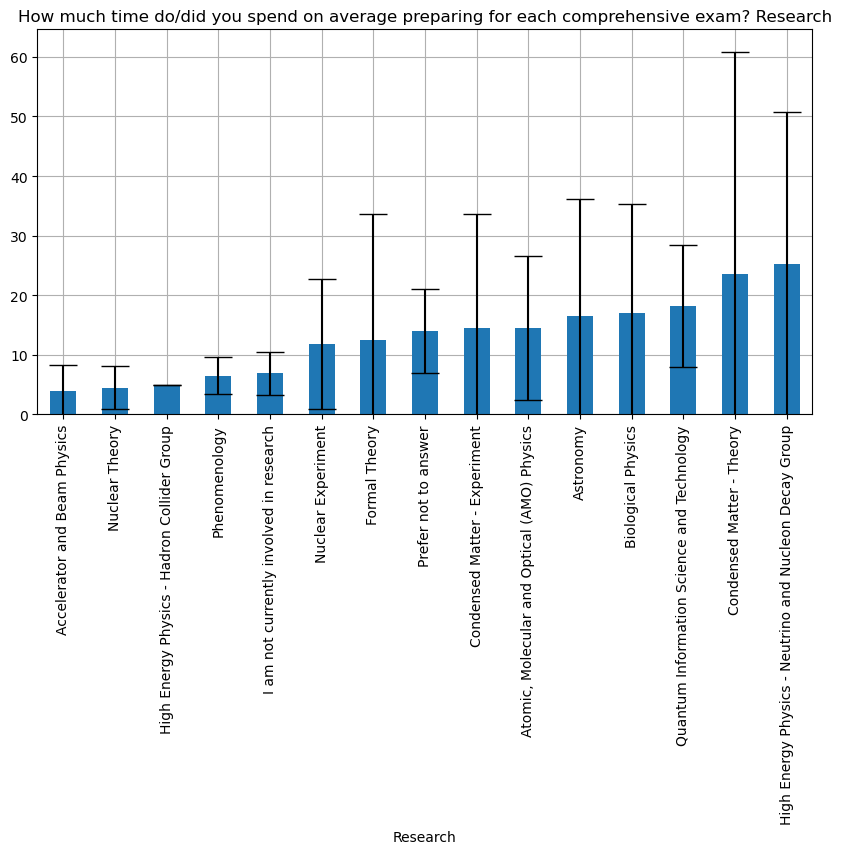

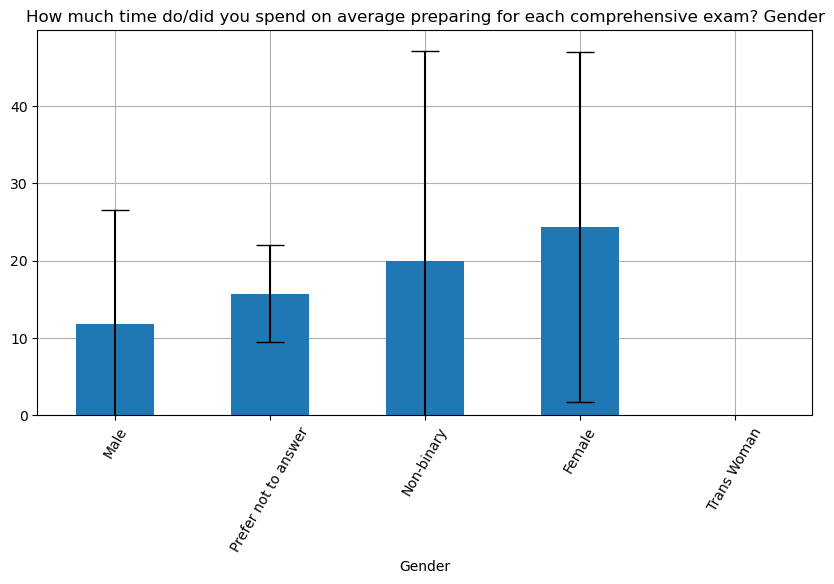

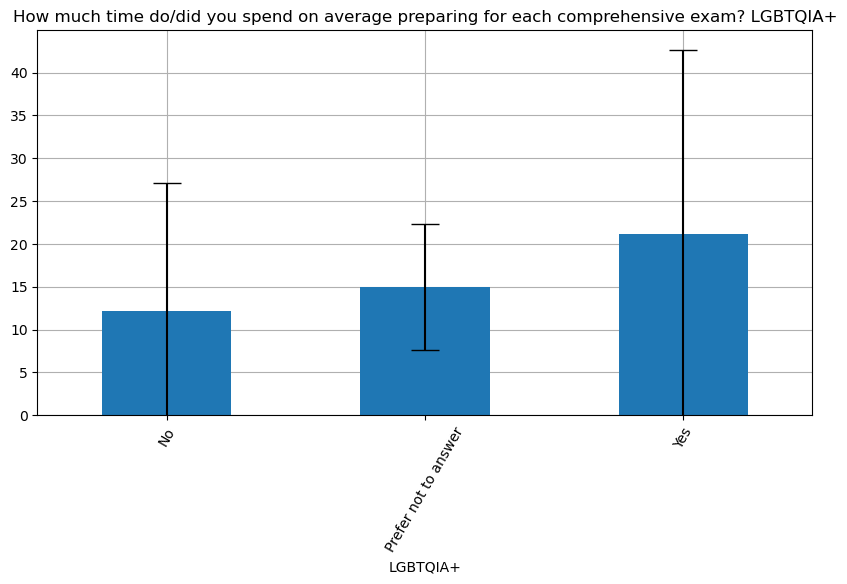

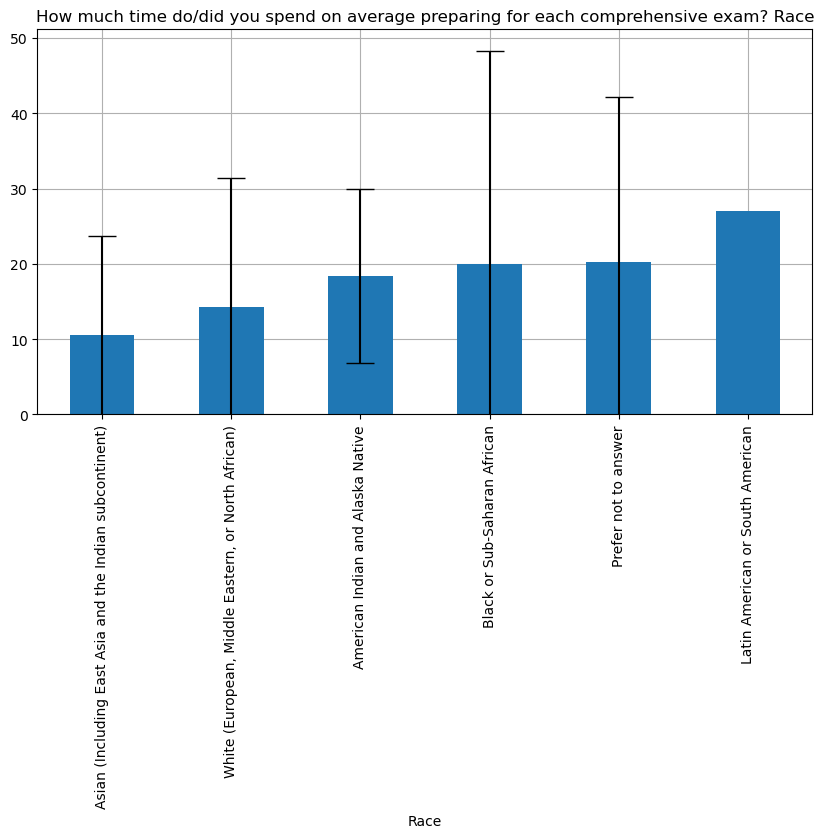

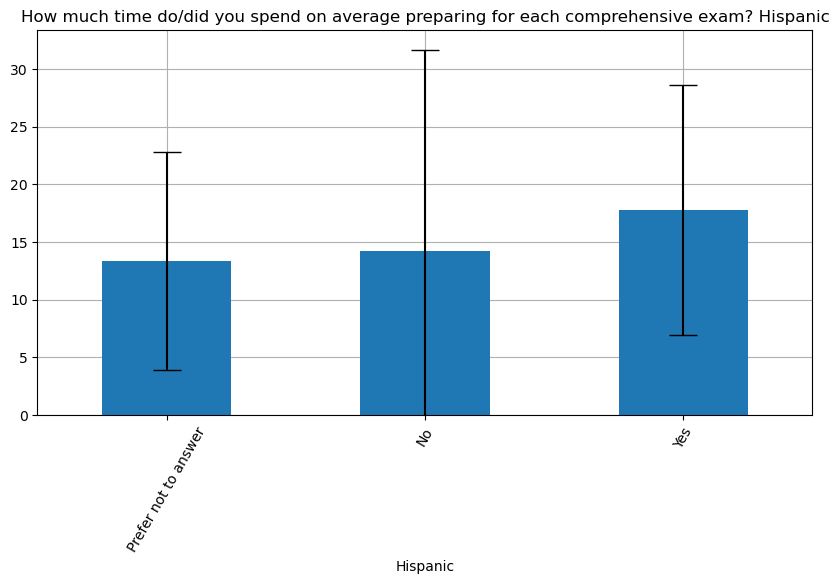

In [19]:
Demographics=['Program', 'Job', 'Research', 'Gender', 'LGBTQIA+', 'Race','Hispanic']

for var in CompsQuestions.keys():
    for dem in Demographics:
        barplot(dem,var,CompsQuestions)

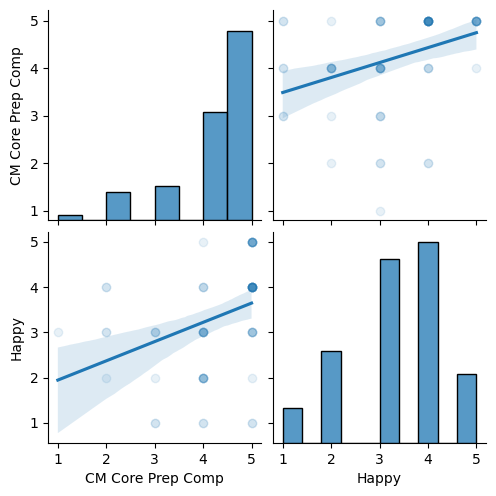

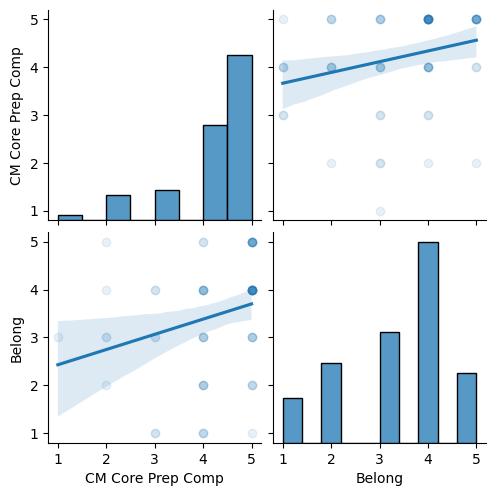

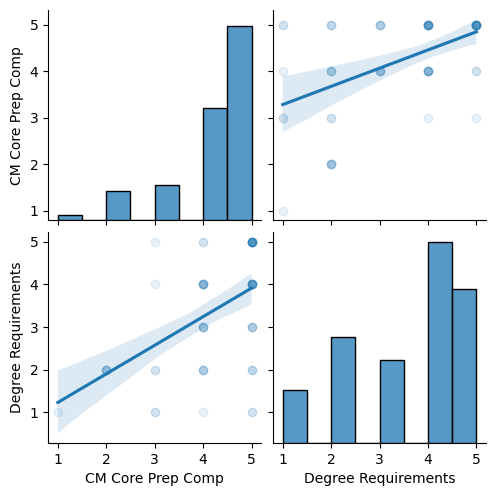

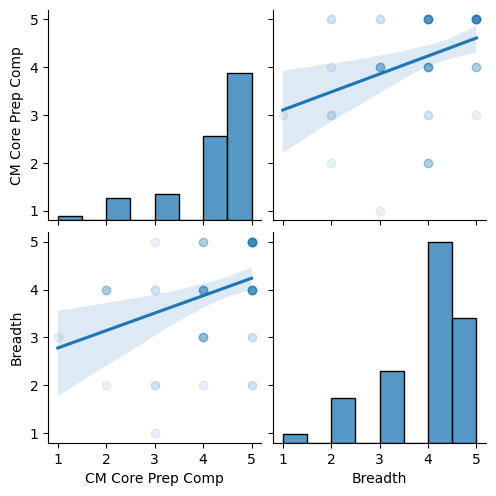

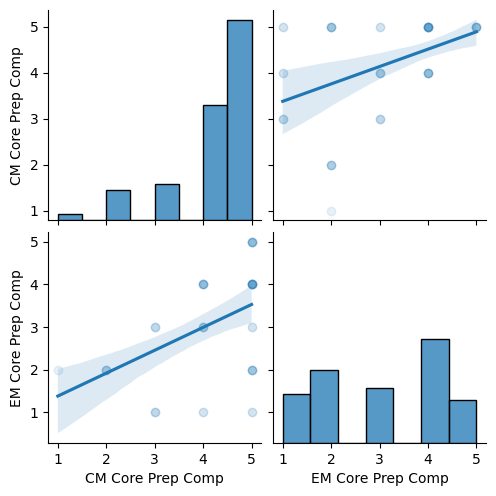

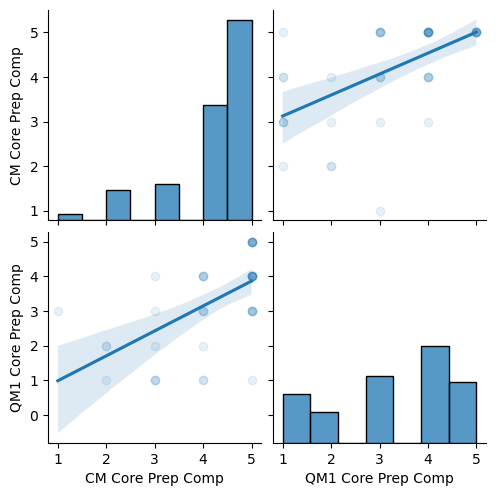

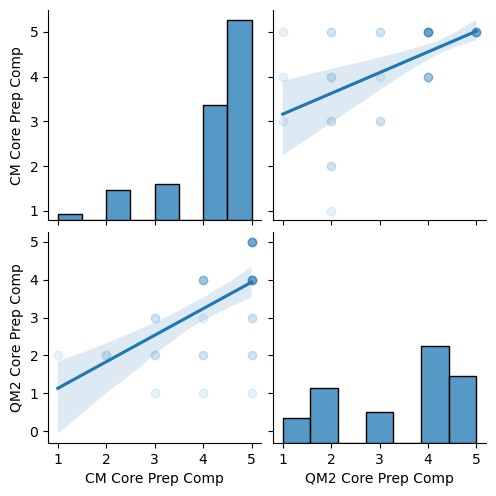

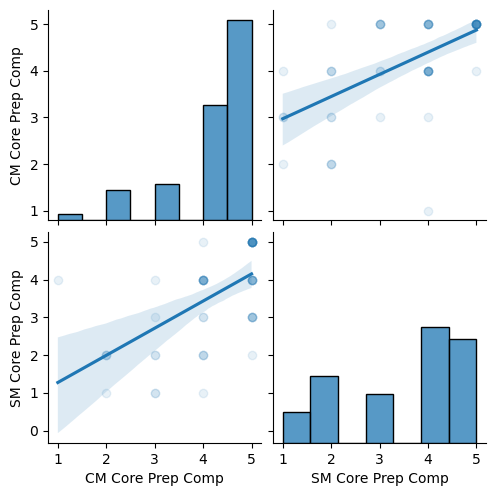

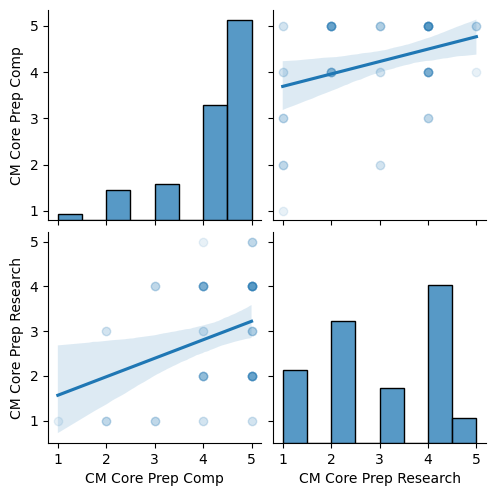

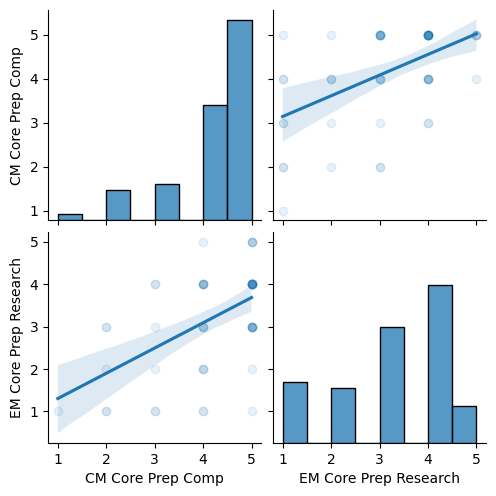

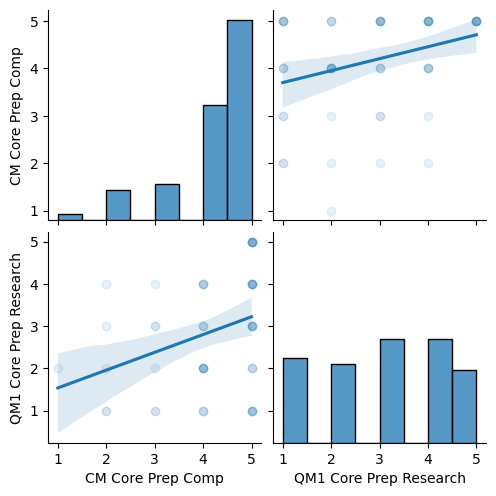

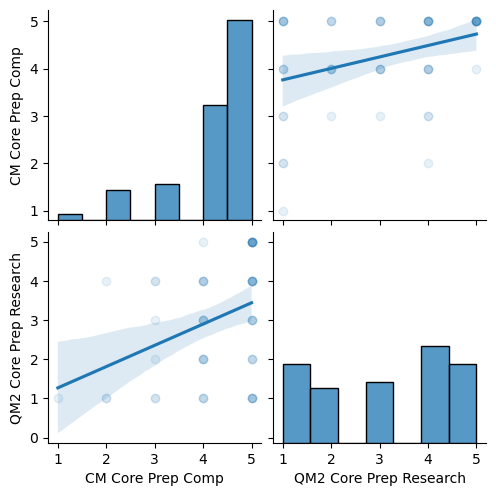

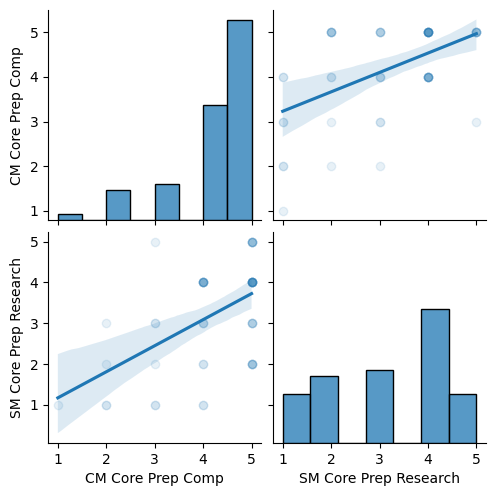

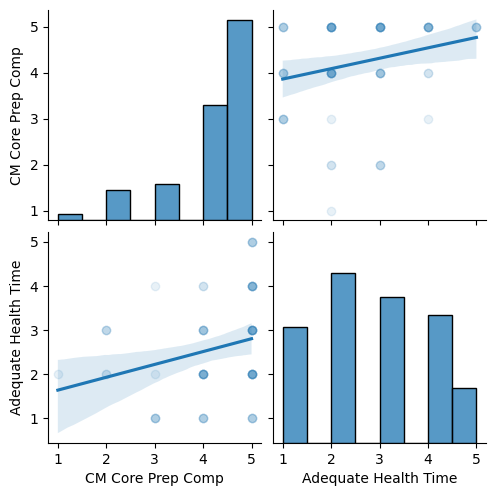

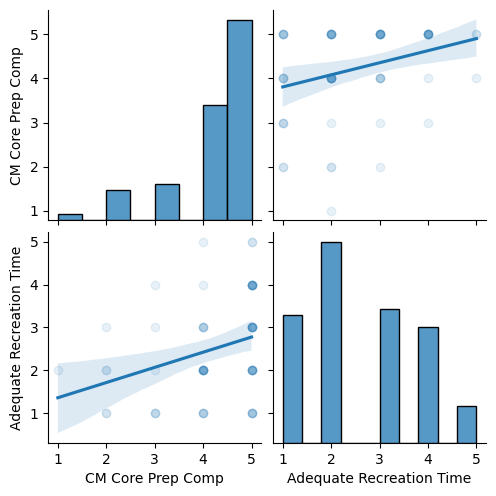

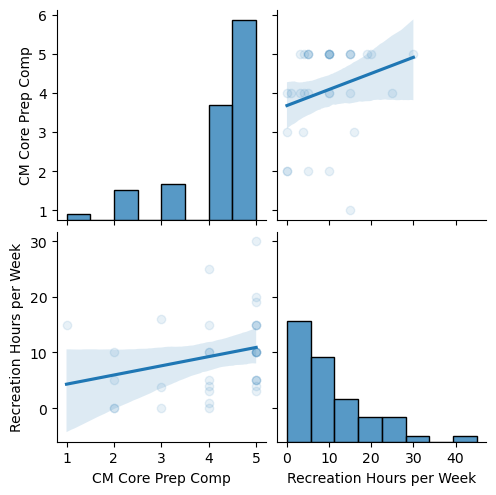

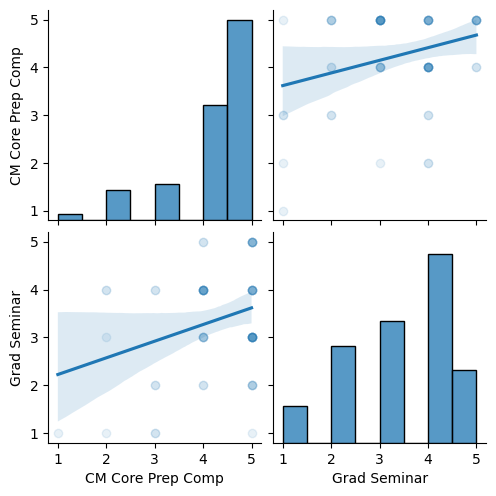

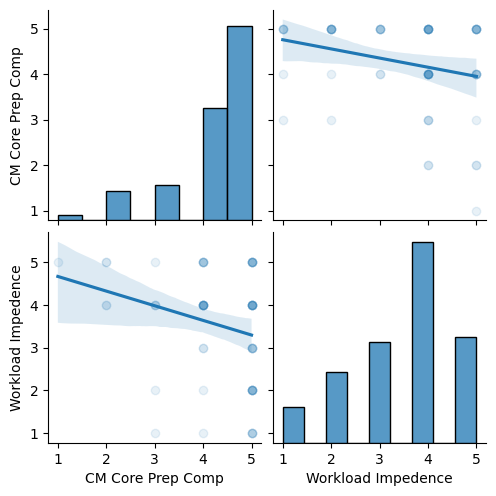

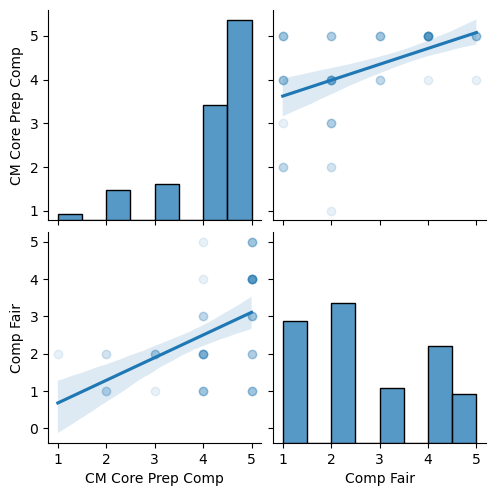

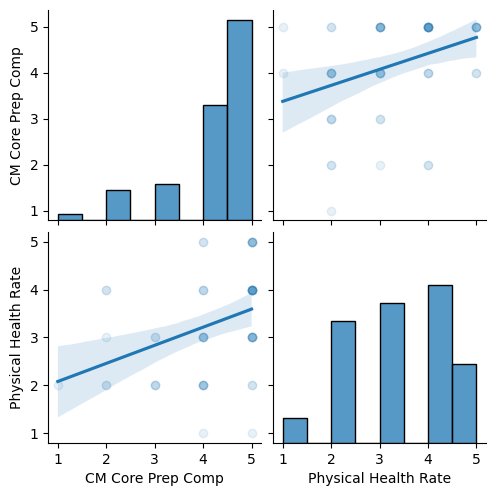

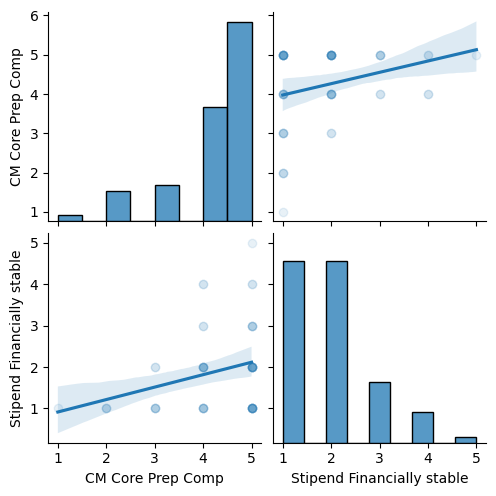

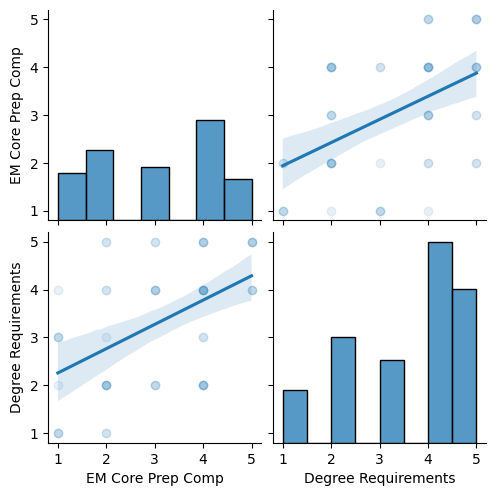

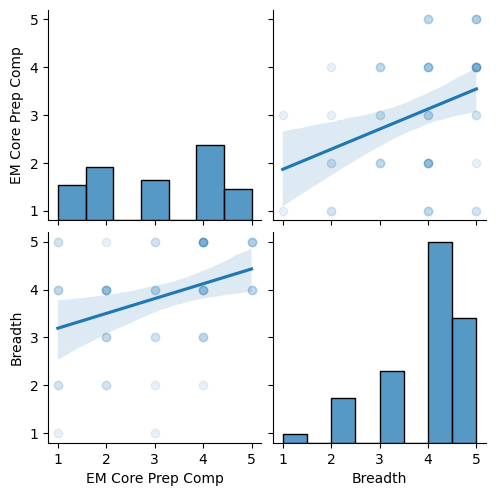

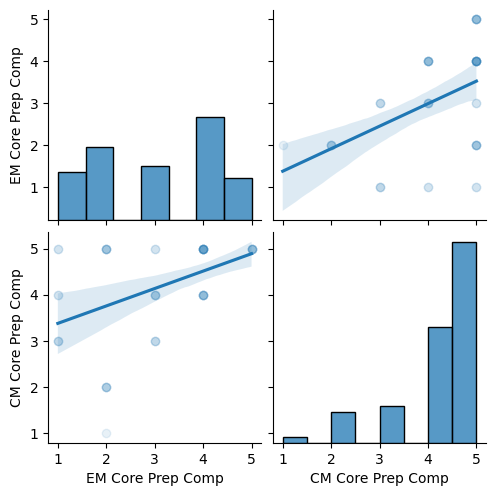

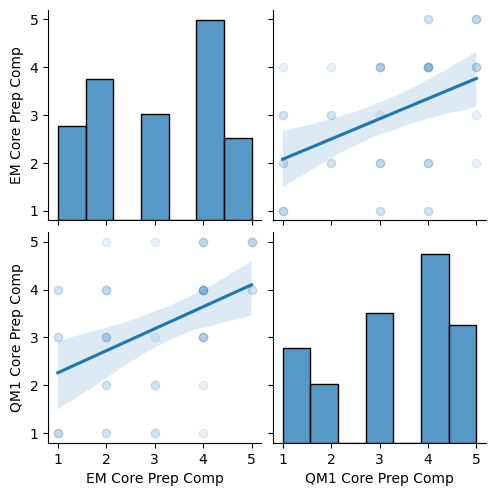

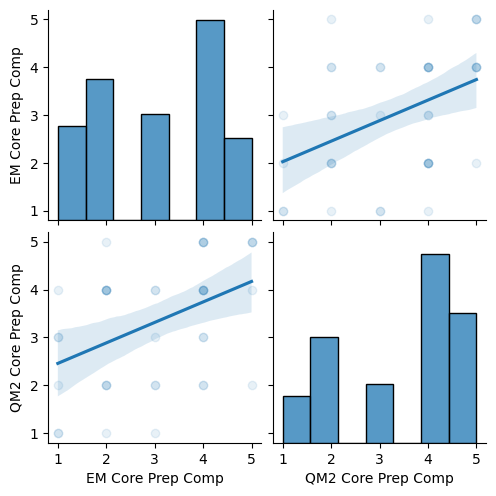

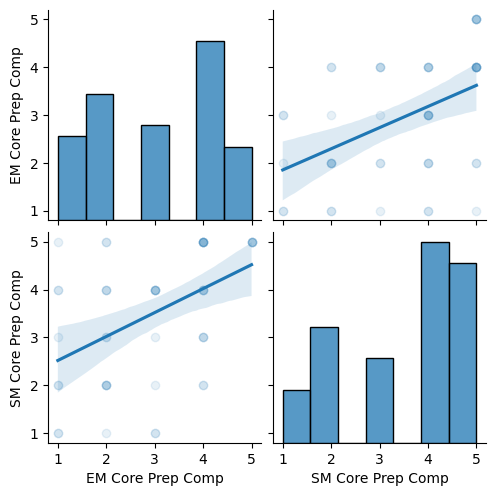

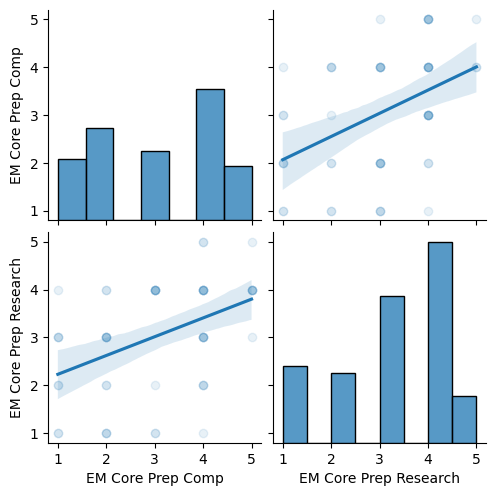

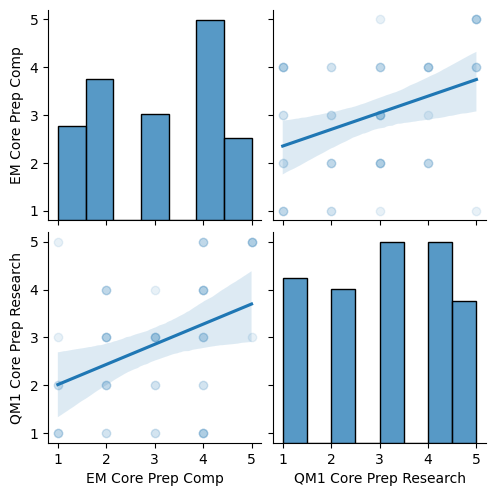

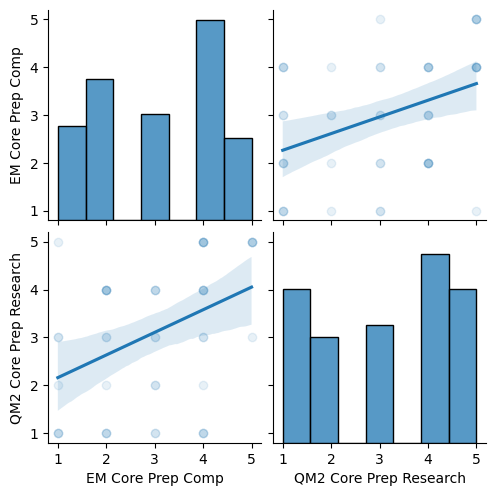

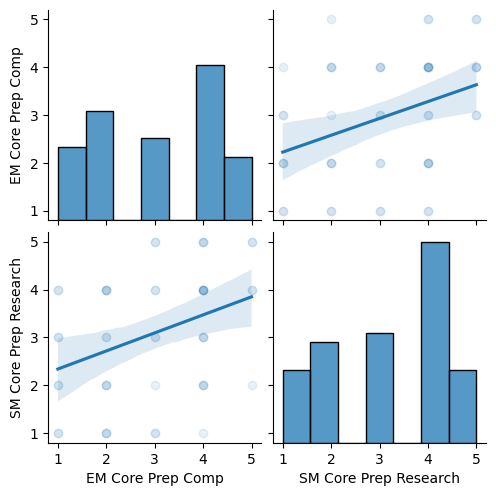

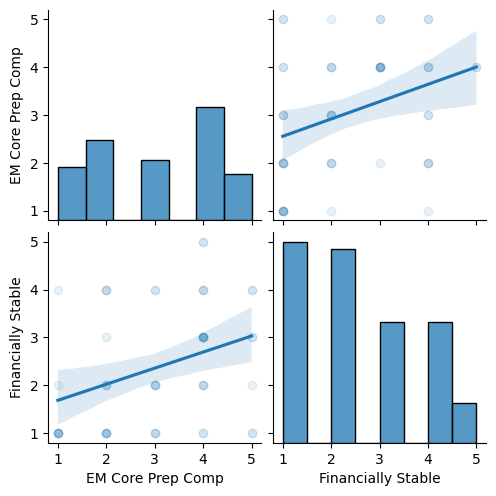

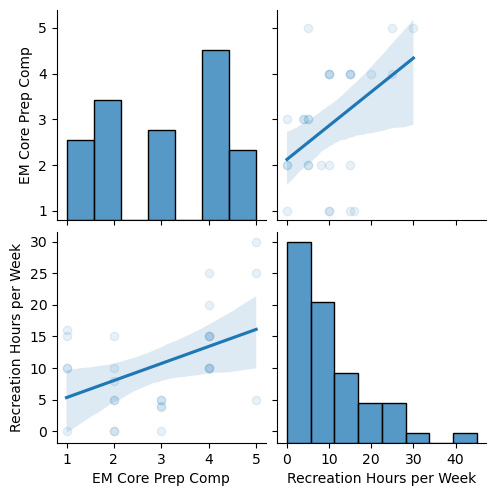

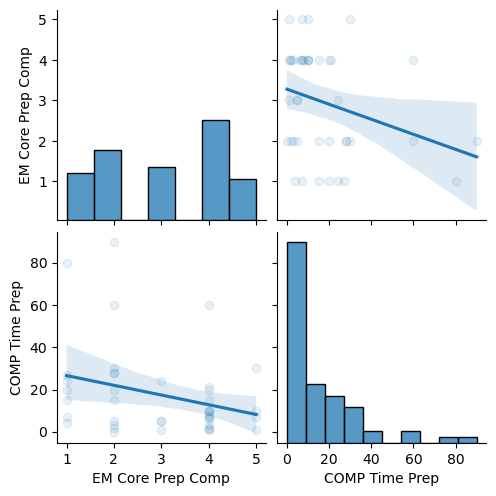

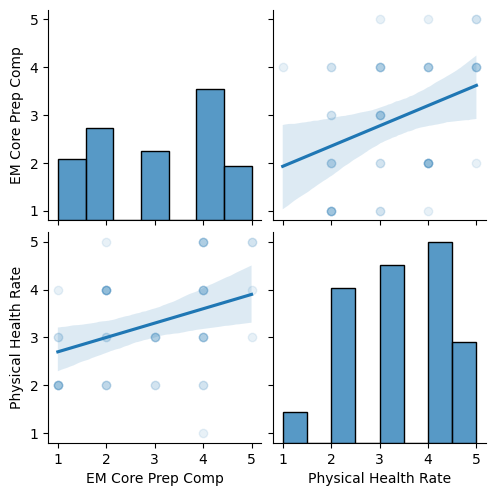

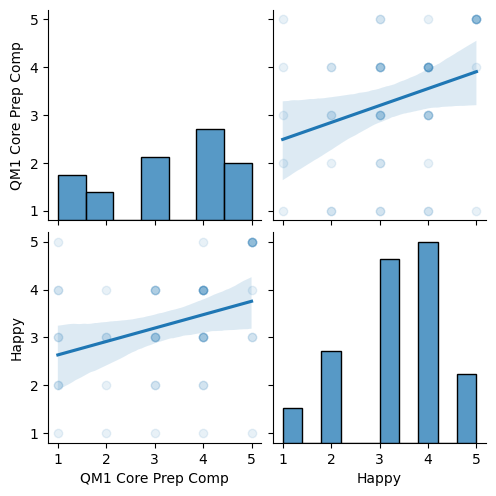

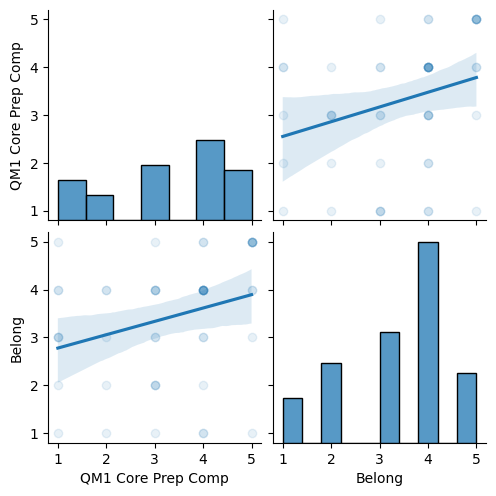

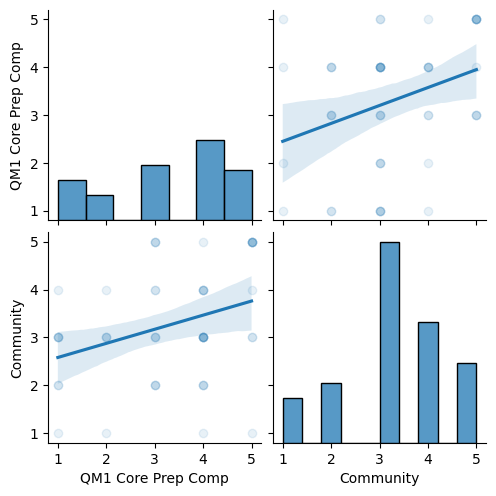

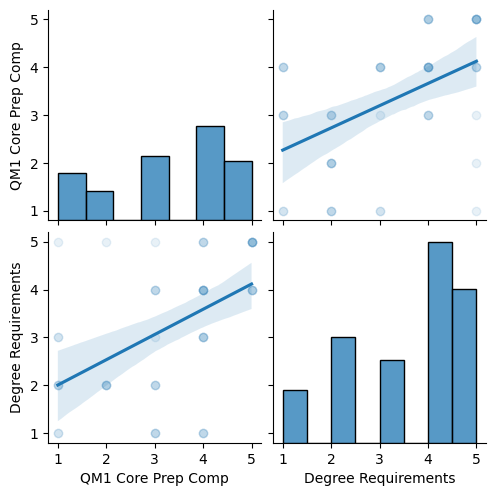

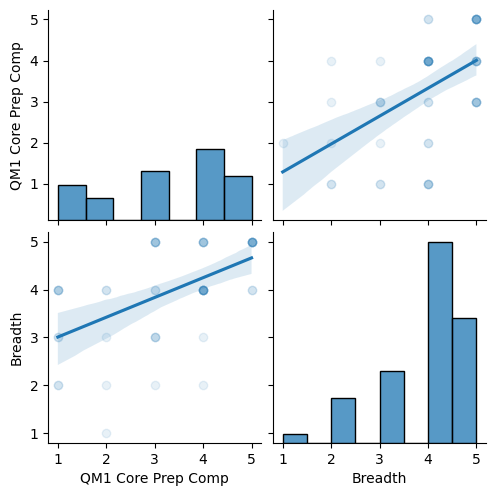

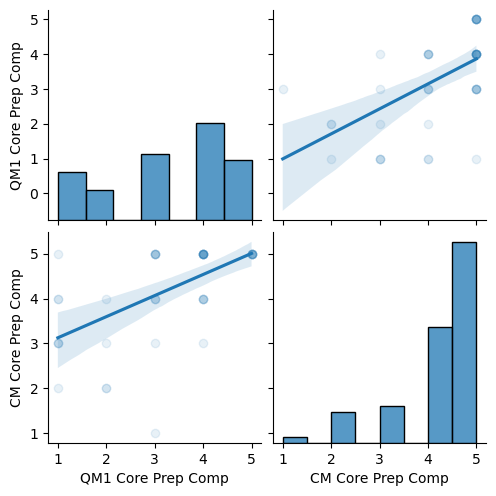

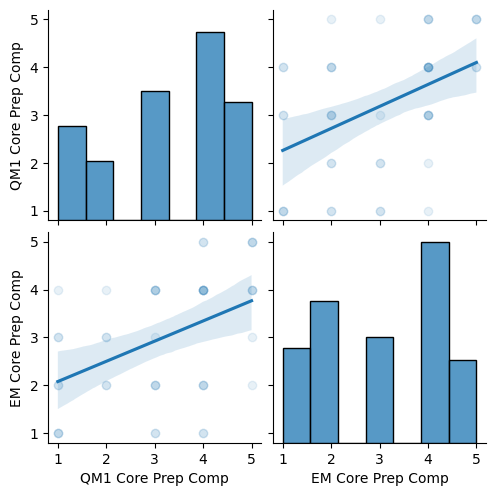

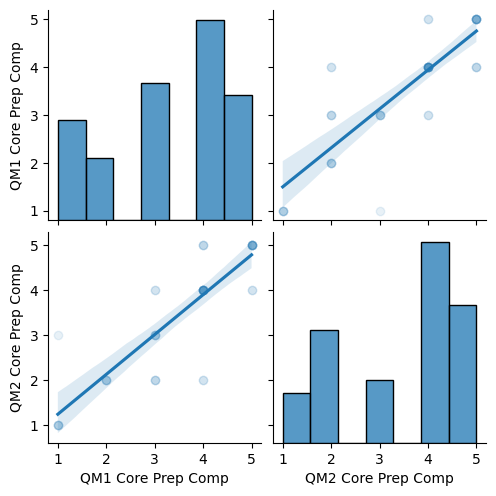

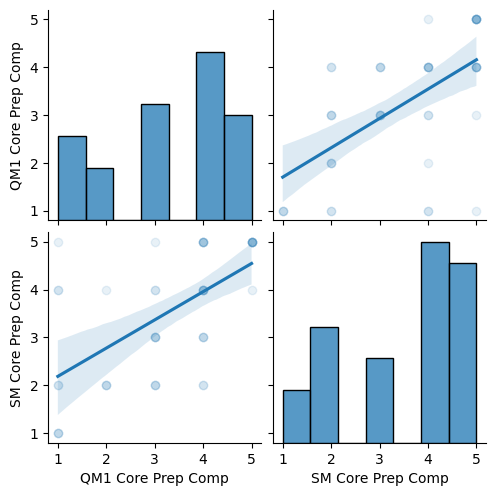

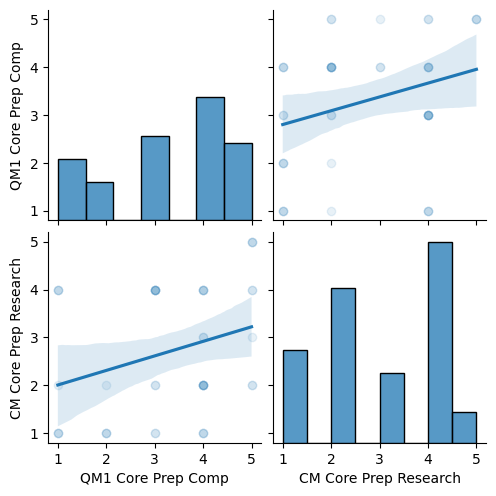

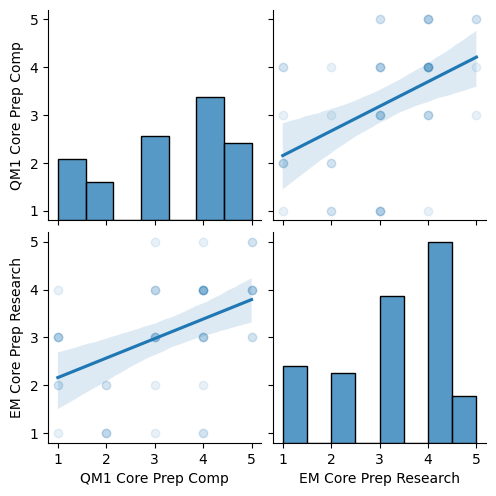

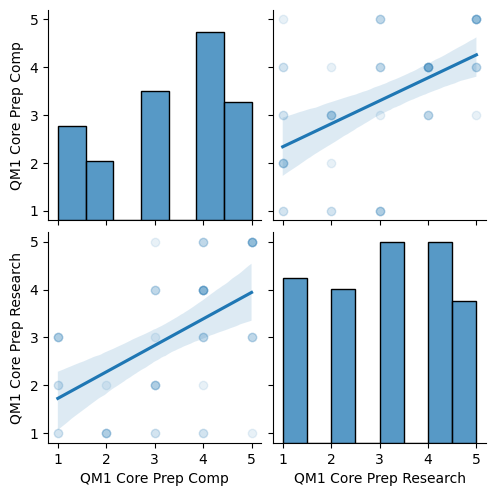

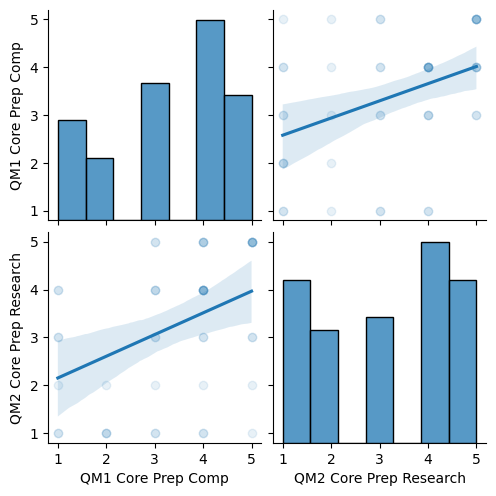

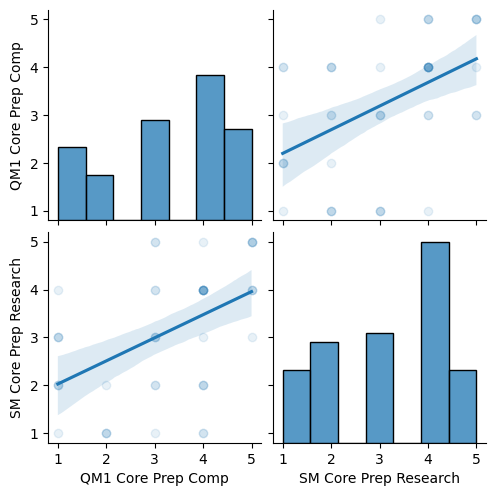

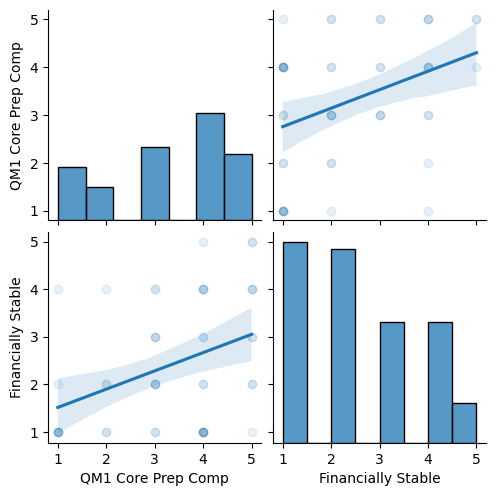

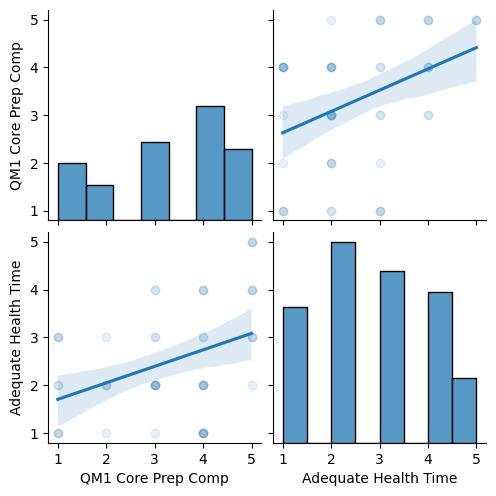

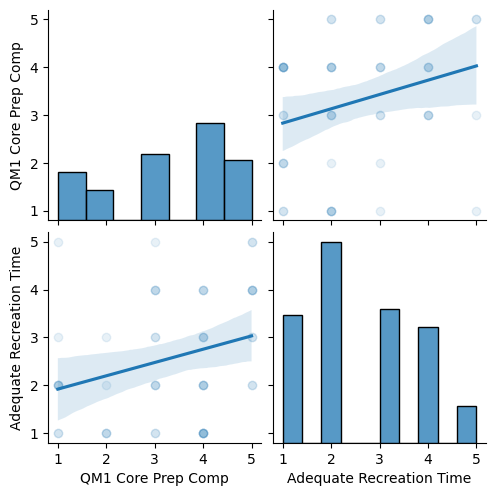

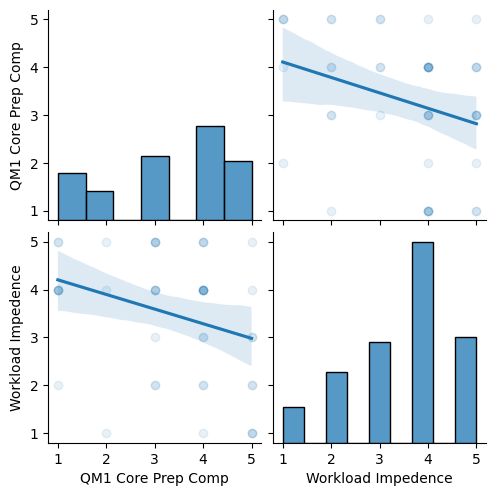

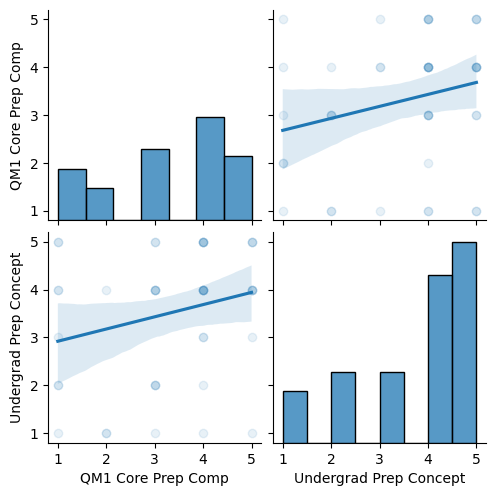

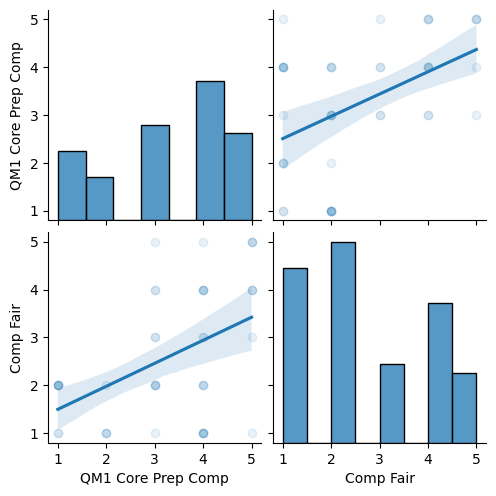

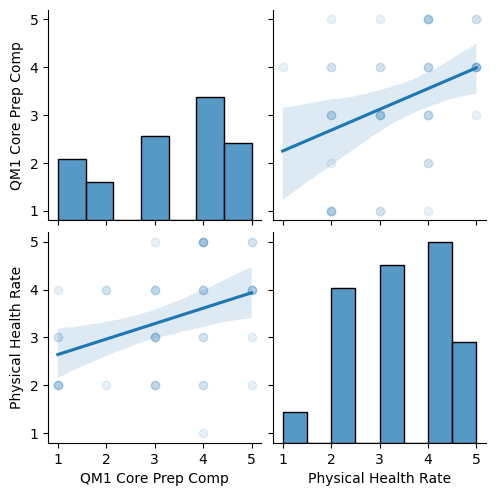

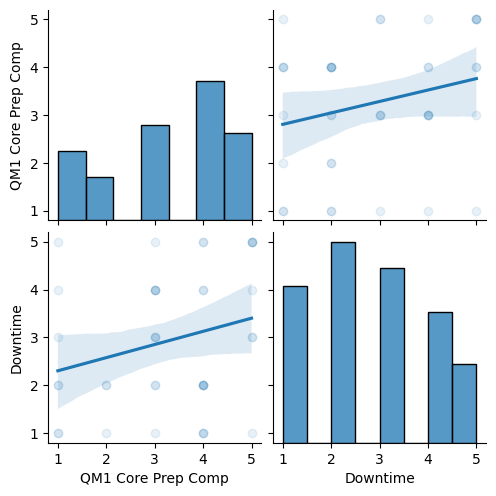

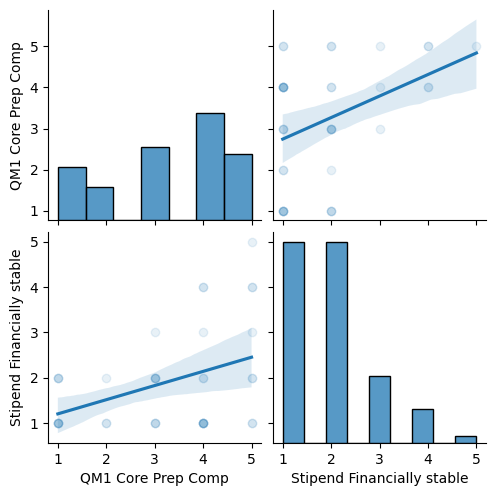

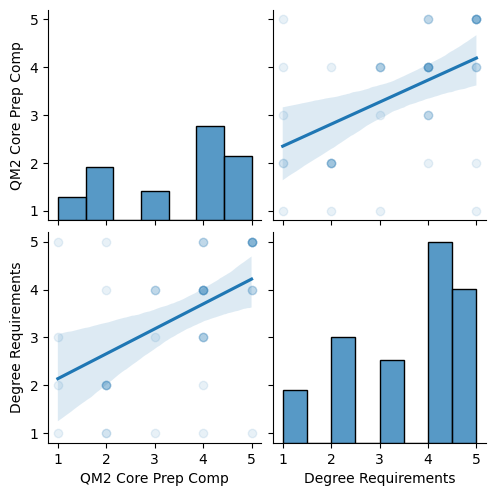

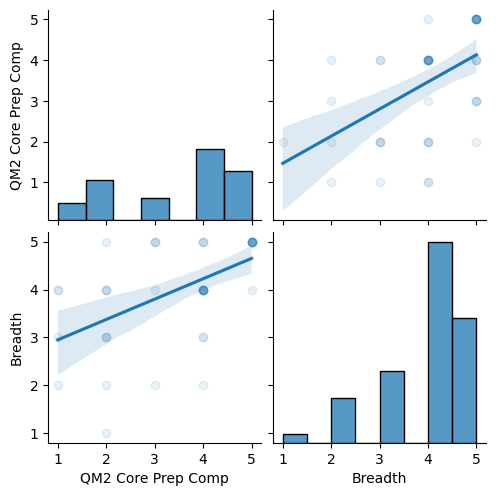

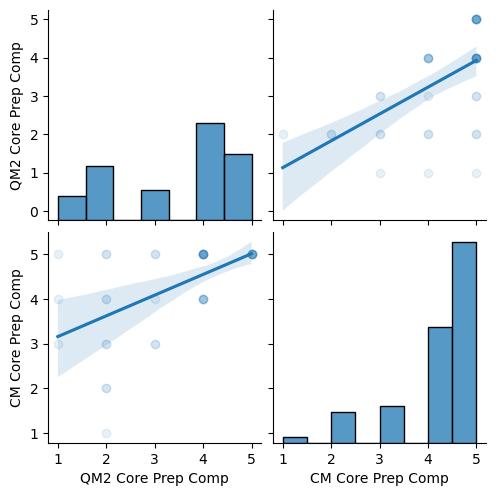

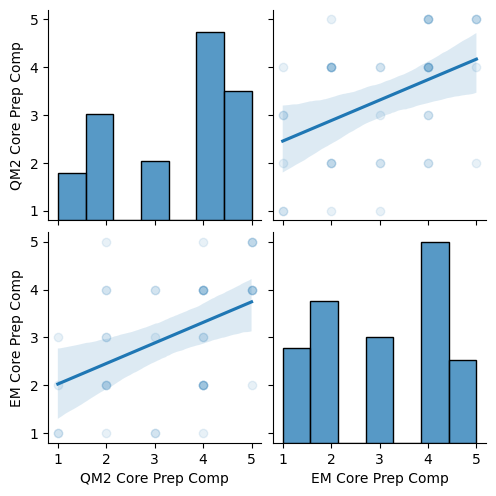

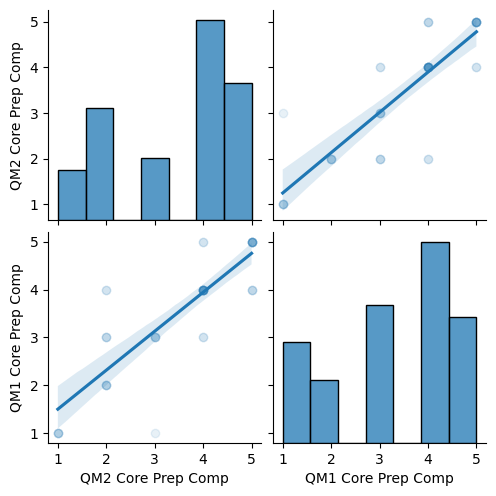

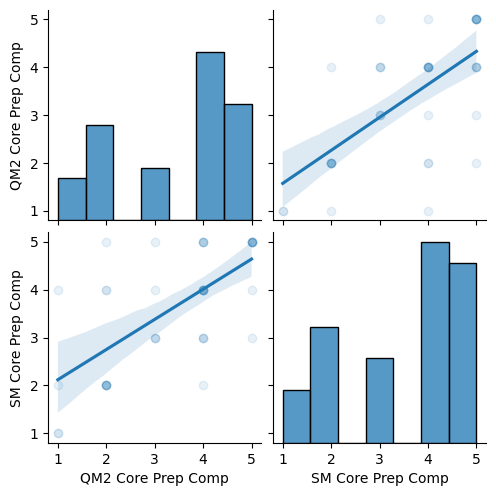

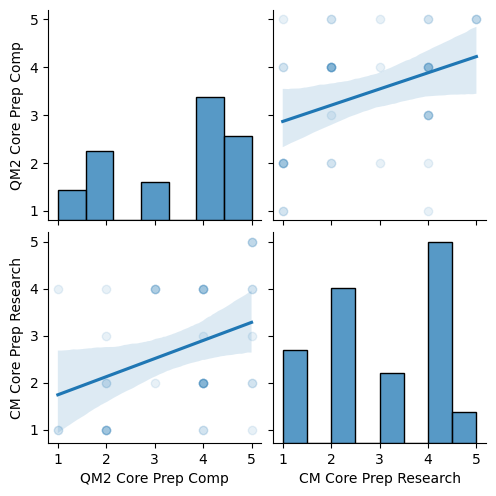

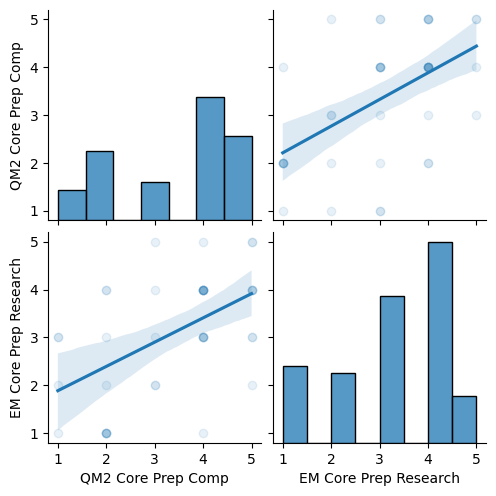

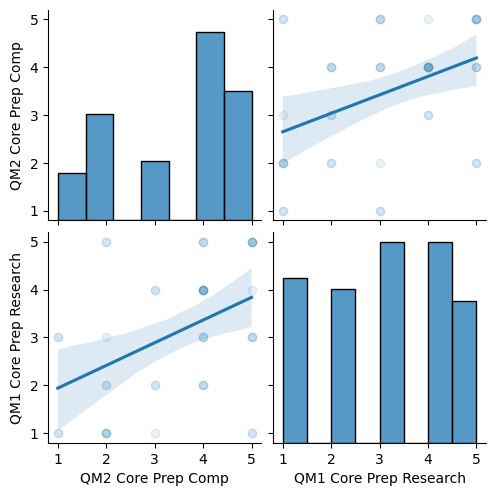

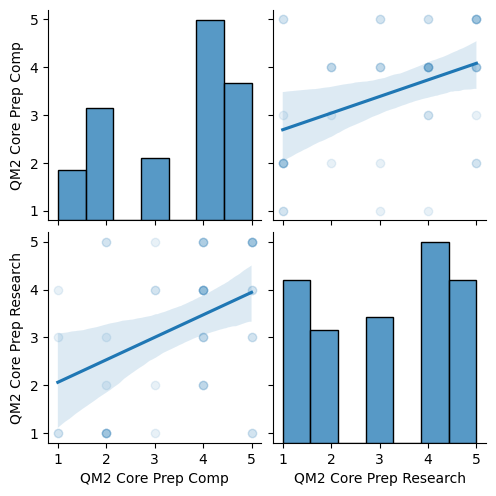

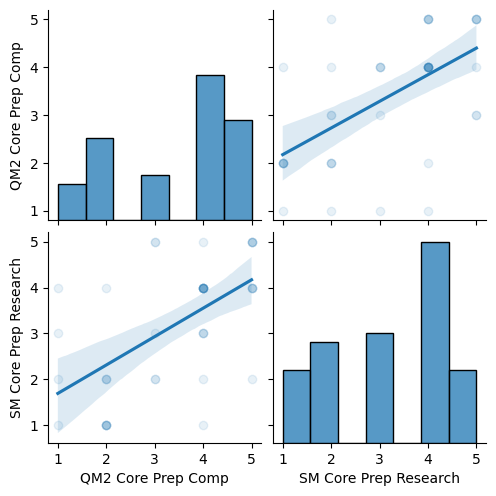

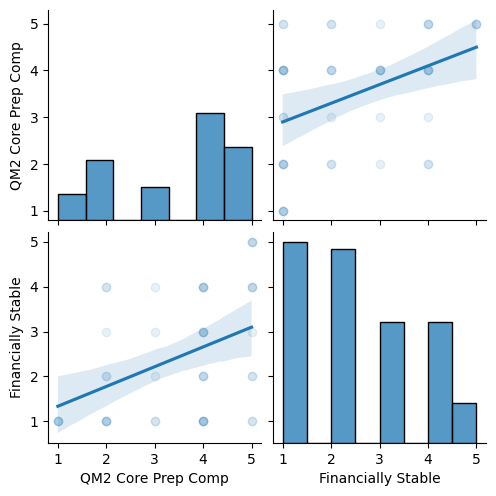

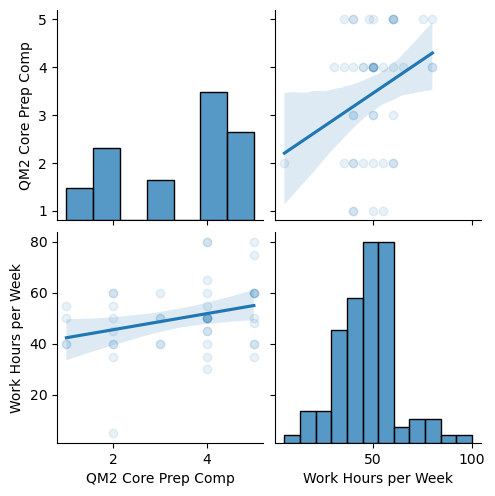

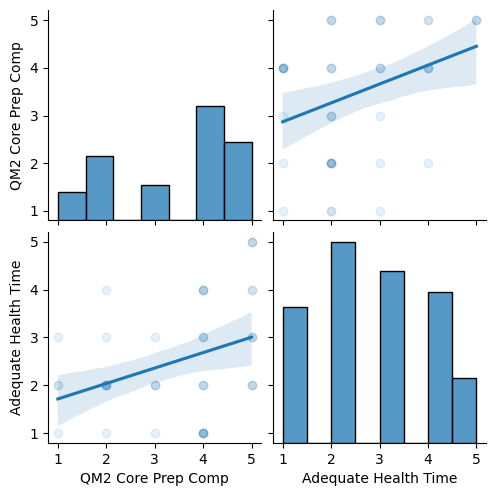

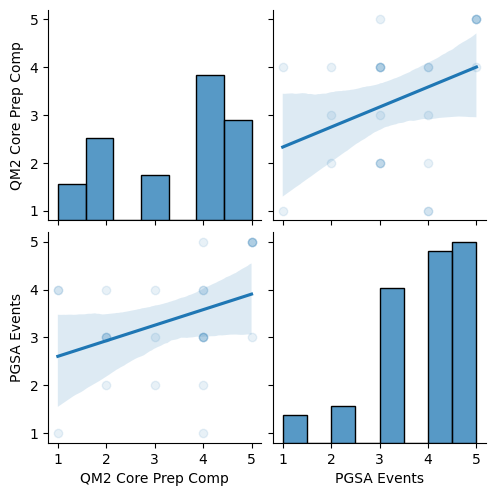

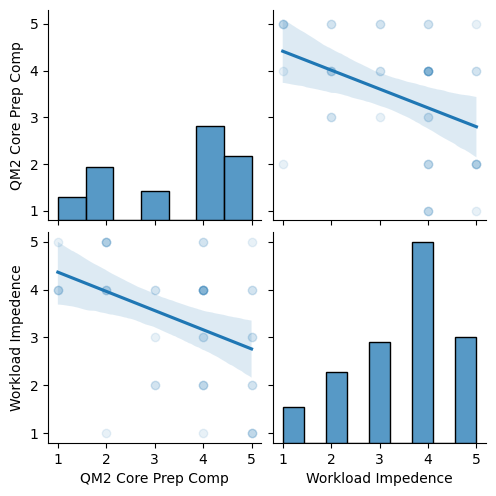

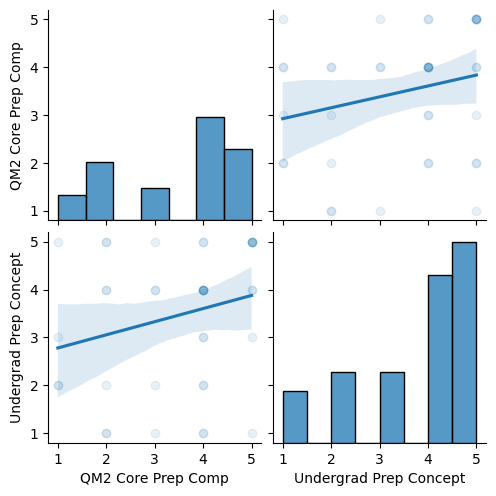

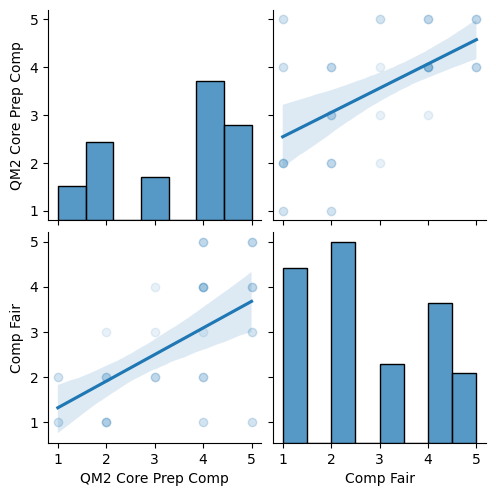

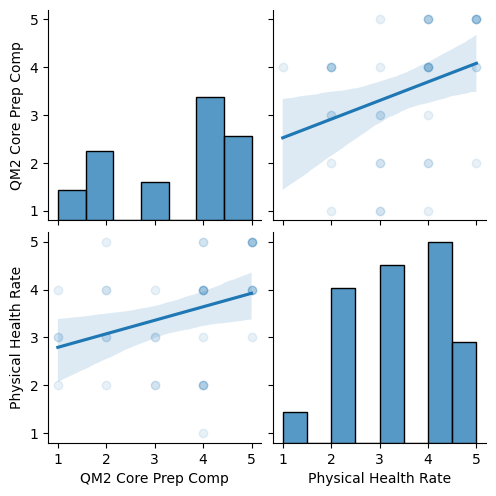

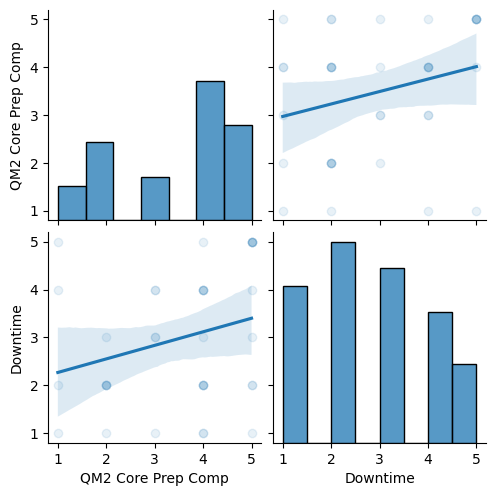

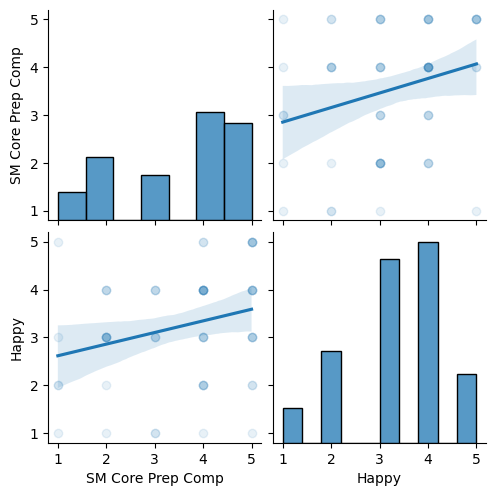

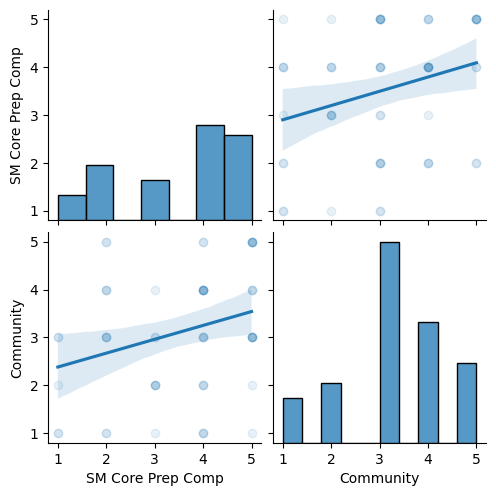

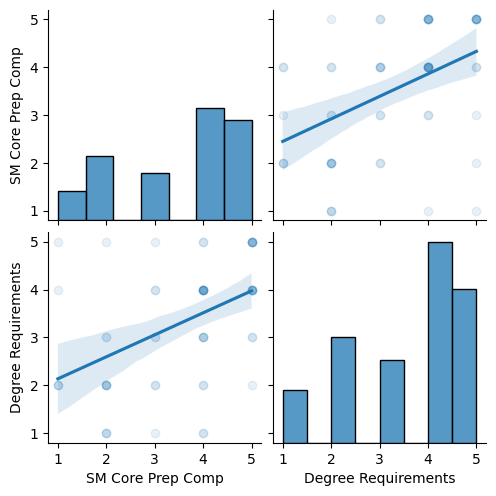

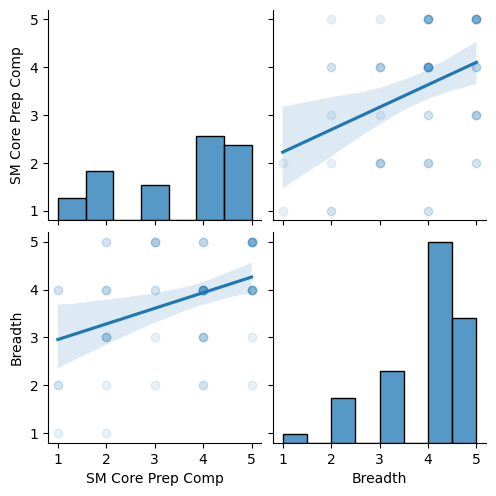

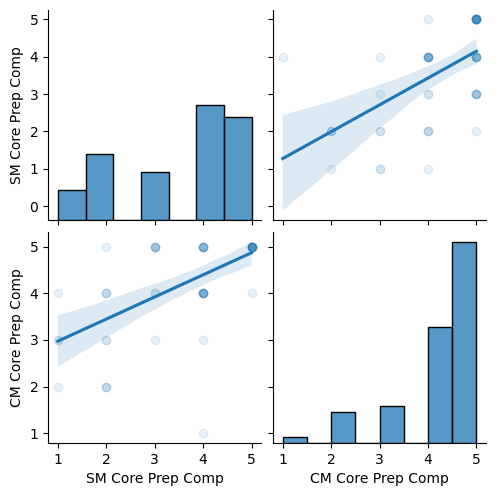

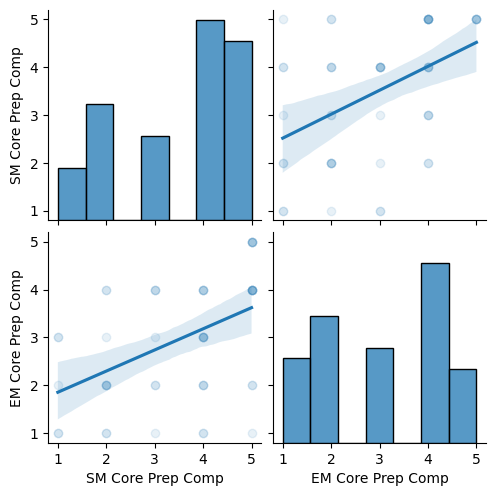

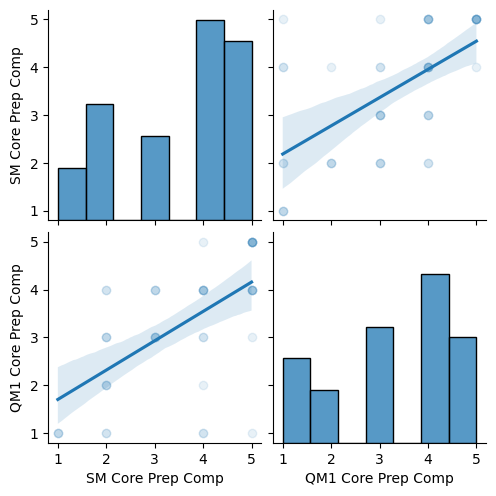

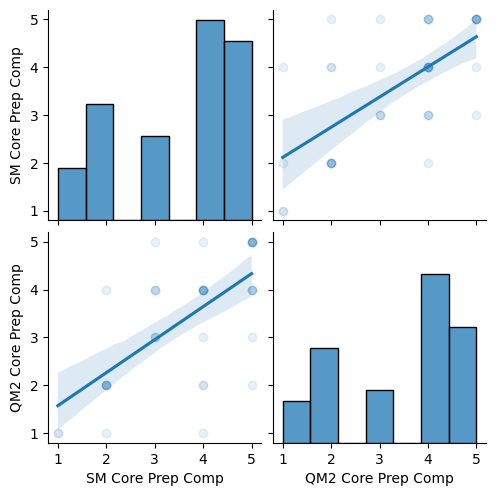

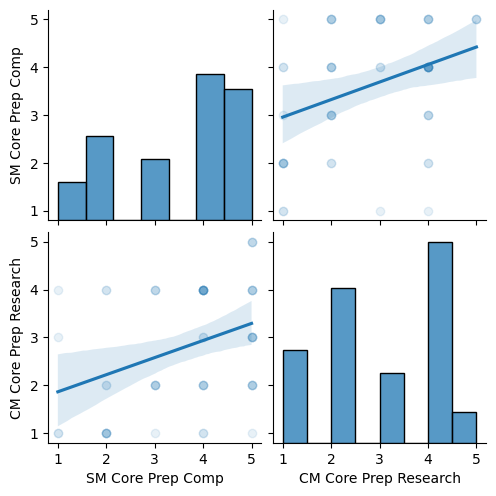

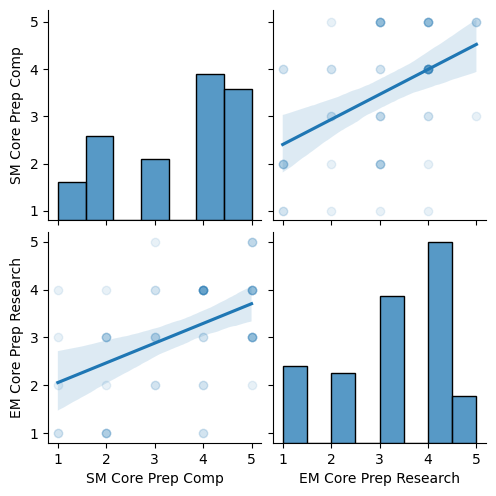

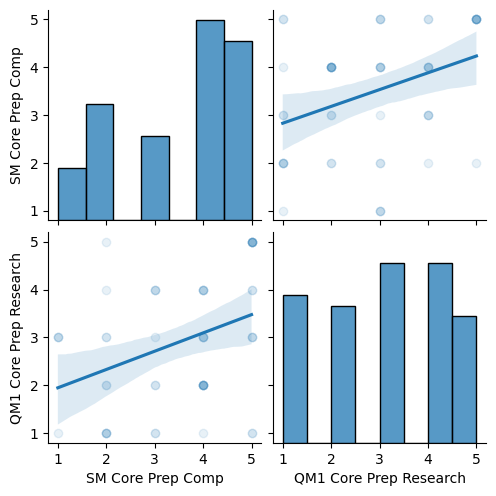

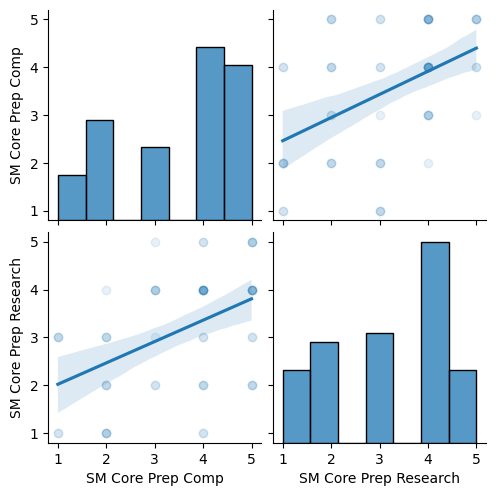

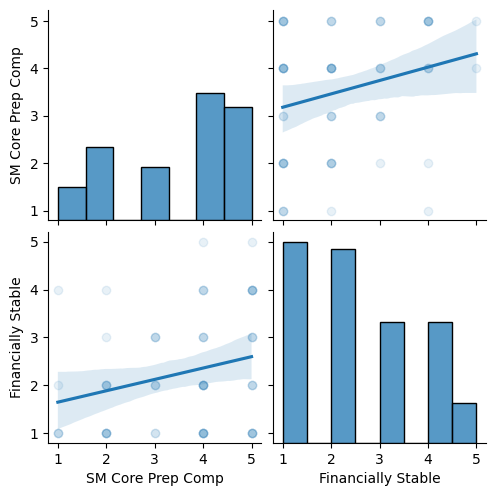

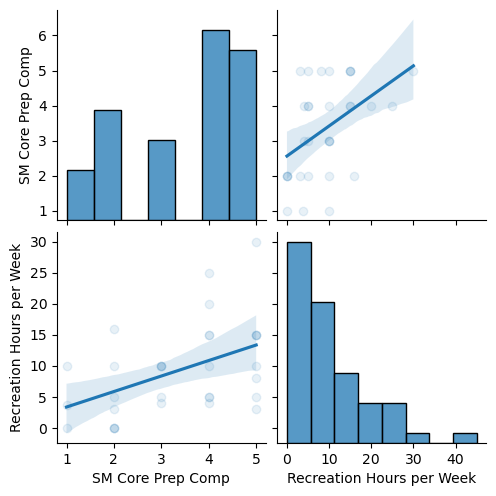

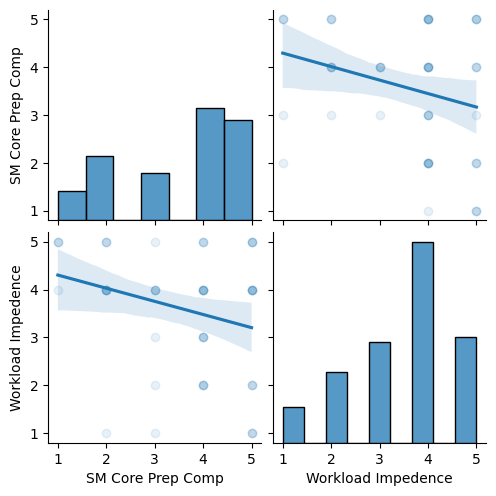

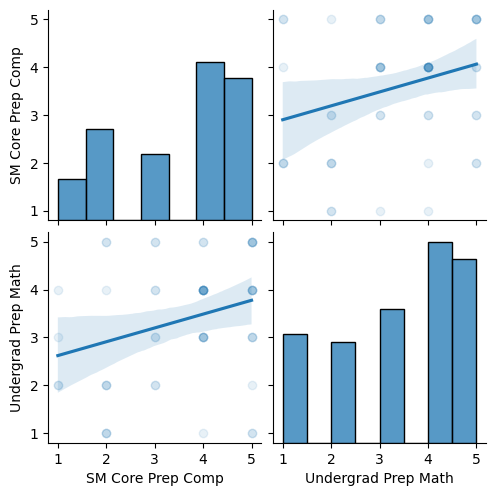

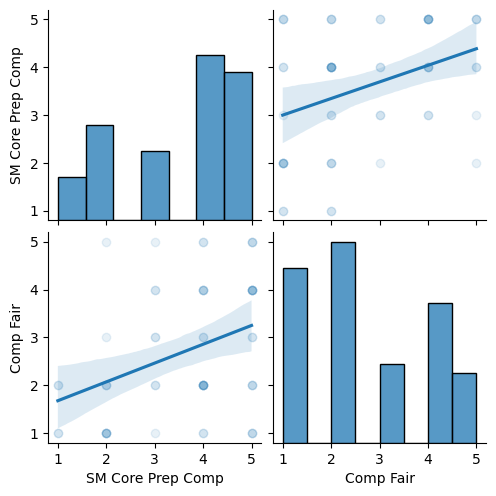

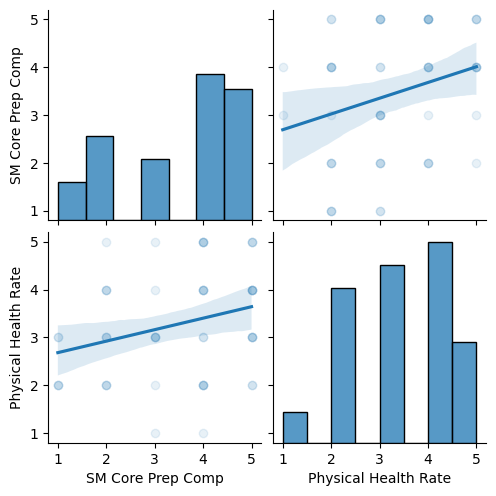

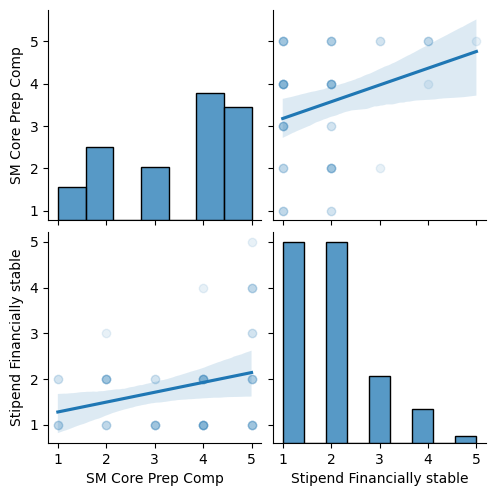

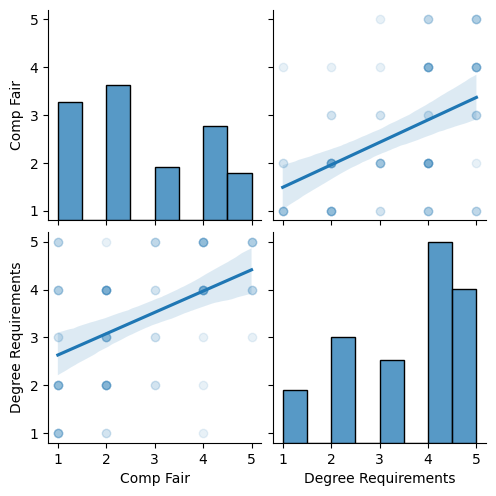

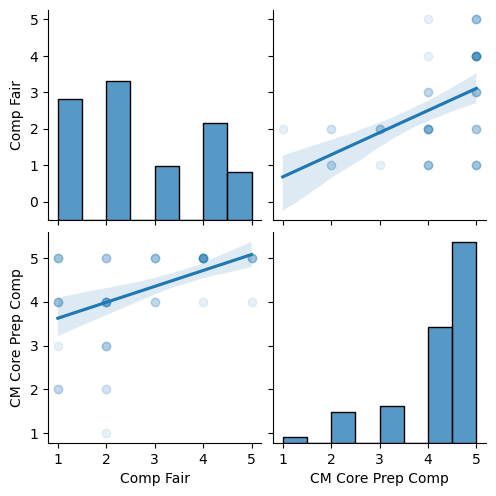

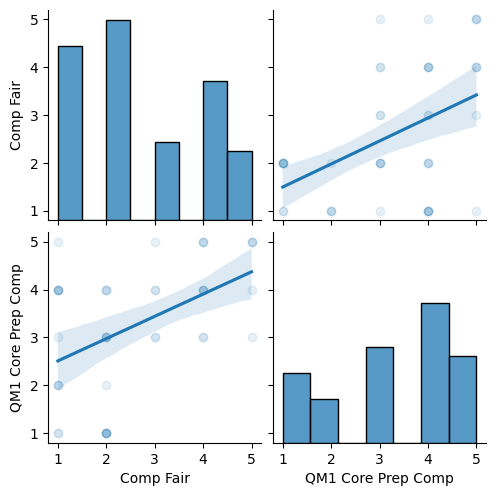

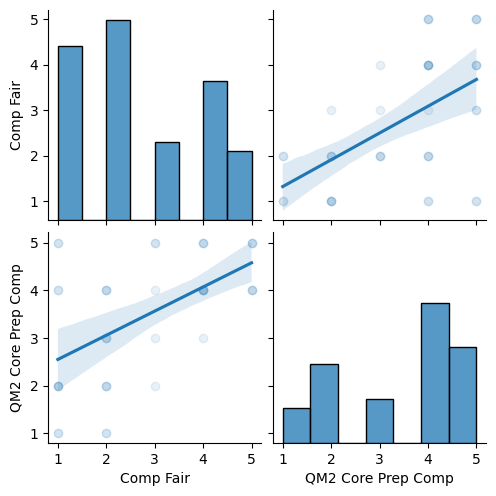

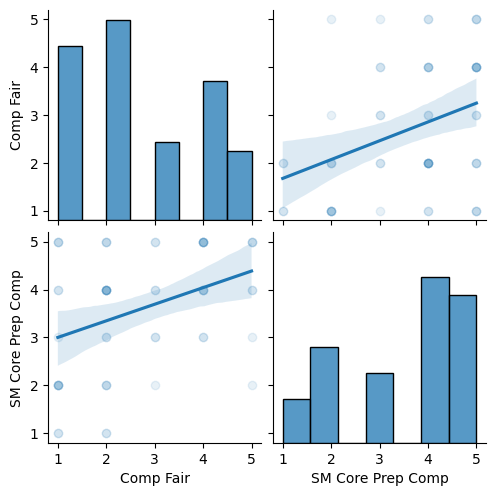

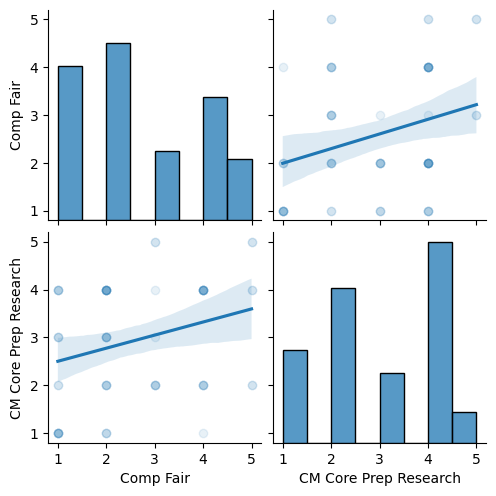

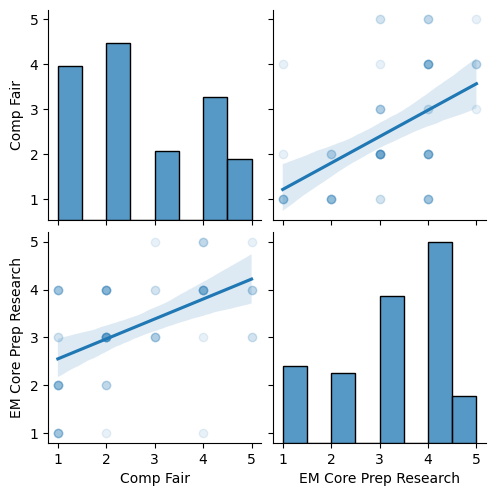

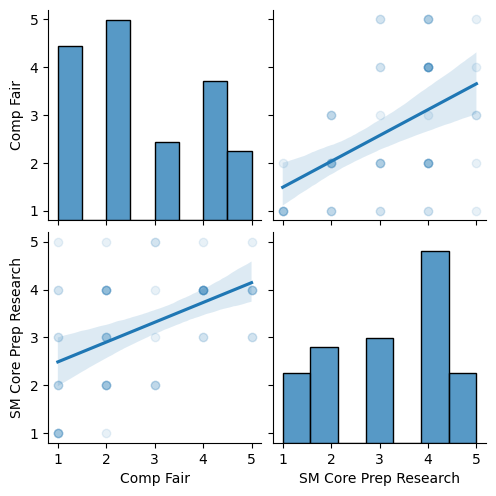

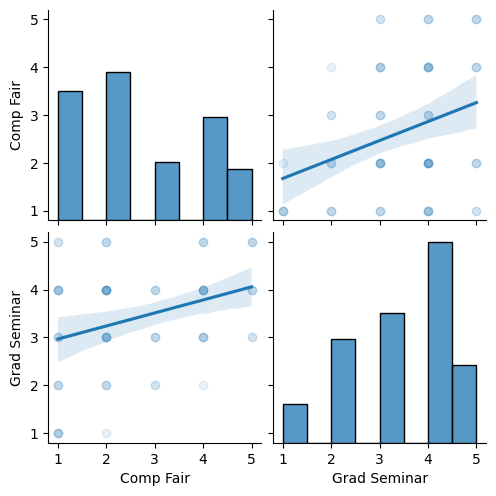

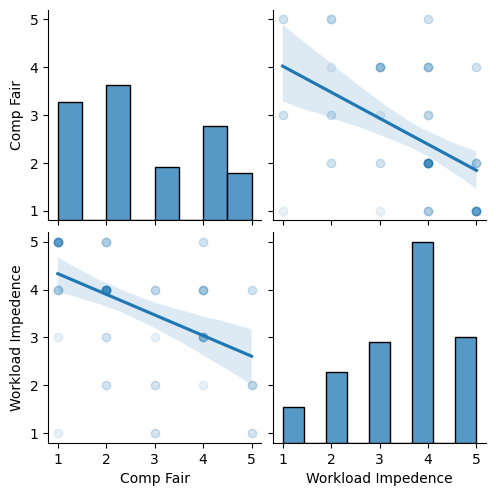

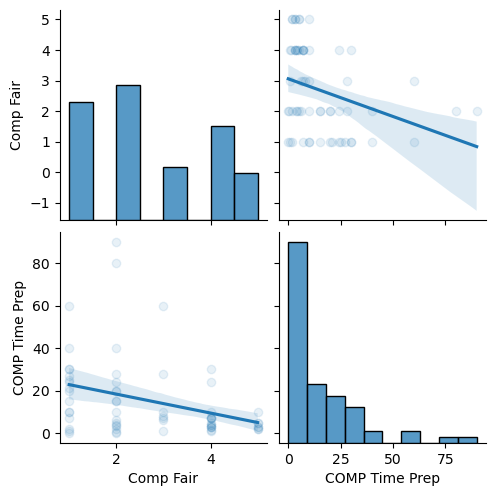

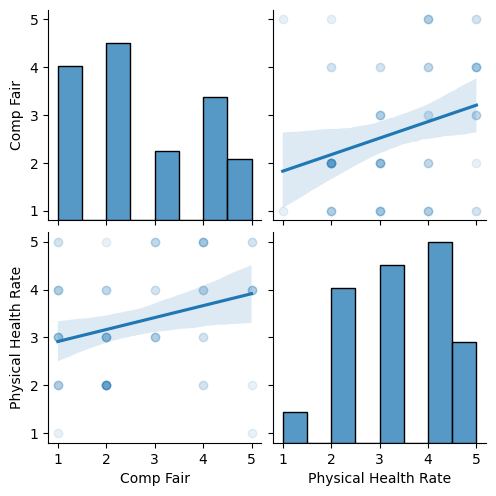

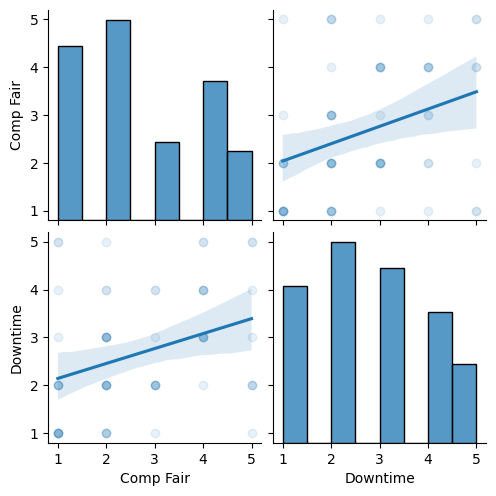

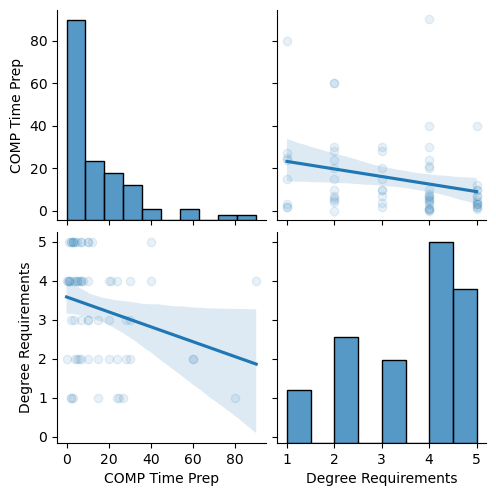

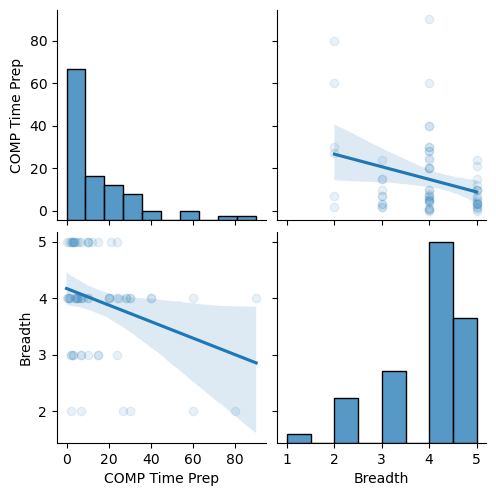

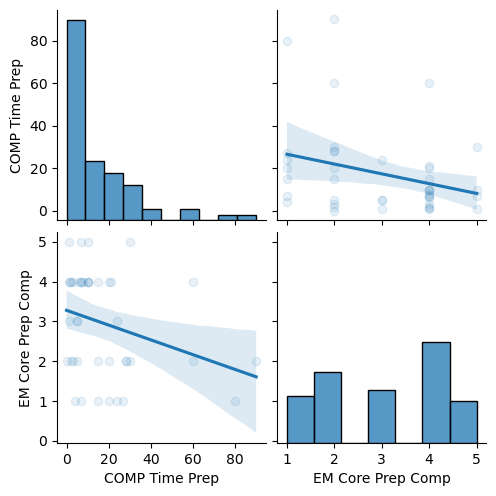

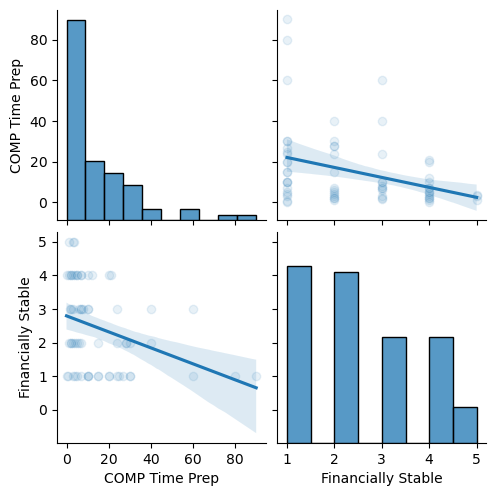

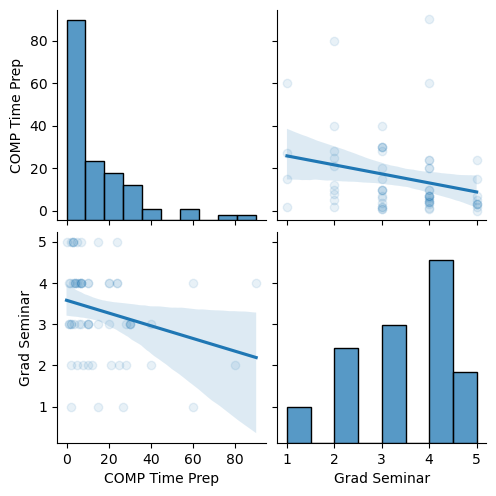

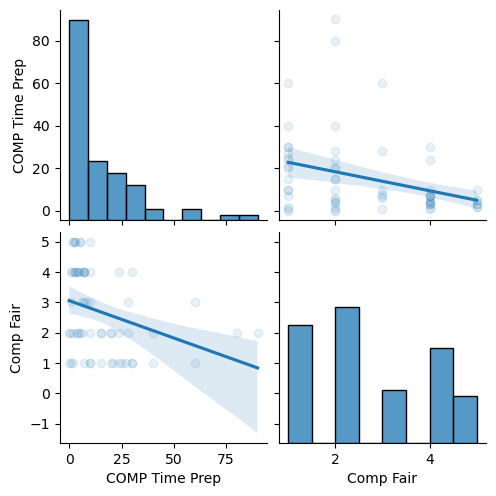

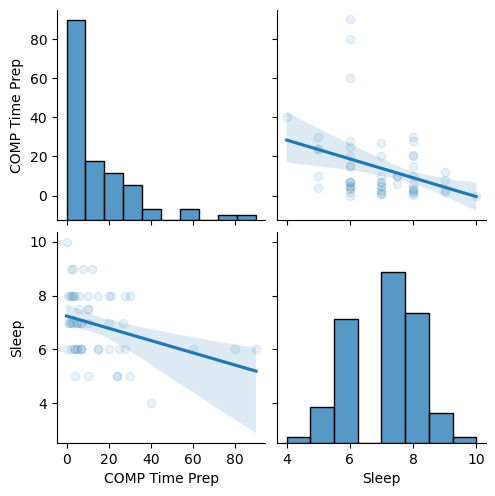

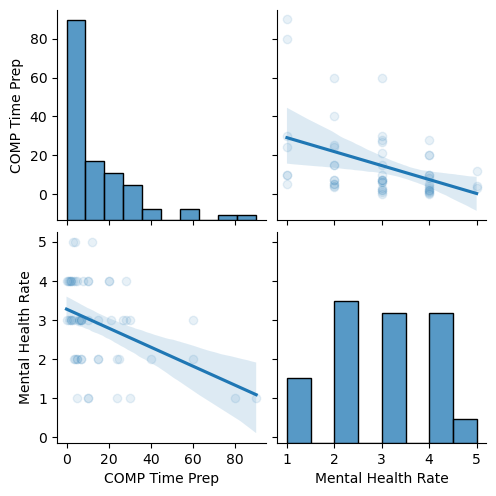

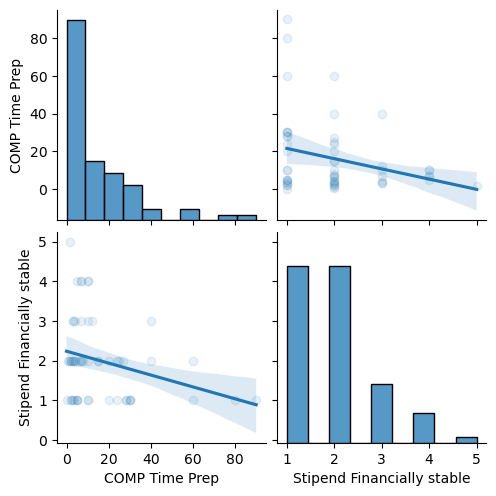

In [15]:
Variables=['Happy', 'Belong', 'Community', 'Degree Requirements', 'Breadth','CM Core Prep Comp', 'EM Core Prep Comp', 'QM1 Core Prep Comp',
        'QM2 Core Prep Comp', 'SM Core Prep Comp', 'CM Core Prep Research','EM Core Prep Research', 'QM1 Core Prep Research',
        'QM2 Core Prep Research', 'SM Core Prep Research', 'Financially Stable','Work Hours per Week', 'Adequate Health Time', 'Health Hours per Week',
        'Adequate Recreation Time', 'Recreation Hours per Week','Department Events', 'PGSA Events','Grad Seminar', 'Grad Astro Lab', 'Workload Impedence',
        'Undergrad Prep Concept', 'Undergrad Prep Math', 'Comp Fair', 'COMP Time Prep','Sleep','Mental Health Rate', 'Physical Health Rate', 'Downtime',
        'Monthly Income', 'Outside Support', 'Necessities percentage','Stipend Financially stable']

for var1 in CompsQuestions.keys():
        for var2 in Variables:
                try:
                        SubQOLData=pd.DataFrame({var1:QOLData[var1],var2:QOLData[var2]})
                        if np.abs(SubQOLData.corr()[var1].values[1])>0.25:
                                ax=sns.pairplot(SubQOLData,kind='reg',diag_kind='hist',plot_kws={'scatter_kws':{'alpha':0.1}})
                                plt.show()
                except:
                        continue